In [1]:
import pandas as pd
import numpy as np

In [2]:
A_df = pd.read_csv("data/A.csv", header=None)
B_df = pd.read_csv("data/B.csv", header=None)
C_df = pd.read_csv("data/C.csv", header=None)

# Convert all string-looking numbers to floats
A = A_df.apply(pd.to_numeric, errors='coerce').values
B = B_df.apply(pd.to_numeric, errors='coerce').values
C = C_df.apply(pd.to_numeric, errors='coerce').values

In [3]:
A_index_df = pd.read_csv("data/index_A.csv")
B_index_df = pd.read_csv("data/index_B.csv")
C_index_df = pd.read_csv("data/index_C.csv")

## Remove Transporation

In [4]:
A_transport_df = pd.read_csv("data/Transportation_A.csv")

In [5]:
# create a dict mapping each provider name to all its indices in A_index_df
mapping = A_index_df.groupby('provider name')['index'].apply(list)

# build a single flat list of all matching indices for the foreground processes
matched_indices_transport = [
    idx
    for name in A_transport_df['provider name']
    if name in mapping
    for idx in mapping[name]
]

In [6]:
import numpy as np

# matched_indices_transport is the list of indices to remove
to_drop = np.array(sorted(set(matched_indices_transport), key=int))

# 1) Remove from A_index_df
mask_keep = ~A_index_df['index'].isin(to_drop)
A_index_df = A_index_df.loc[mask_keep].copy()

# 2) Remove corresponding rows and columns from A
A = np.delete(A, to_drop, axis=0)  # remove rows
A = np.delete(A, to_drop, axis=1)  # remove columns

# 3) Remove the same columns from B (keep rows)
B = np.delete(B, to_drop, axis=1)

# 4) Reset the index column in A_index_df
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

## Remove and aggregate Electricity

In [7]:
A_elec_df = pd.read_csv("data/Electricity_A.csv")

In [8]:
# Inputs assumed:
# A : numeric numpy array (rows x cols)
# A_index_df : DataFrame with columns ["index", "provider name", "flow name", ...]
# A_elec_df : DataFrame with column ["provider name"] listing all electricity providers
# The indices in A_index_df["index"] align with both row and column positions of A.

# 0) Build the set of electricity provider names
elec_names = set(A_elec_df['provider name'].dropna().astype(str).unique())

# 1) Find their indices in A_index_df
elec_idx = A_index_df.loc[A_index_df['provider name'].astype(str).isin(elec_names), 'index'].astype(int).unique()

# 2) Locate the mix row index (must exist)
mix_name = "Electricity Mix (Global)"
mix_rows = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int).unique()
if len(mix_rows) == 0:
    raise ValueError("Electricity Mix (Global) not found in A_index_df['provider name'].")
mix_idx = int(mix_rows[0])

# Ensure the mix row is not purged
elec_idx_set = set(map(int, elec_idx))
elec_idx_wo_mix = sorted(elec_idx_set - {mix_idx})

# 3) Aggregate: add all electricity rows (except the mix row) into the mix row, column-wise
if len(elec_idx_wo_mix) > 0:
    # in case of NaNs
    add_block = np.nansum(A[elec_idx_wo_mix, :], axis=0)
    A[mix_idx, :] = np.nan_to_num(A[mix_idx, :]) + np.nan_to_num(add_block)

# 4) Decide what to drop
rows_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity rows except the mix row
cols_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity columns except the mix column

# (Optionally also drop the mix COLUMN; keep it if you want to retain that process as a column)
# To ALSO drop the mix column, uncomment the next line:
# cols_to_drop = np.array(sorted(elec_idx_set), dtype=int)

# 5) Remove rows/columns from A and columns from B
if rows_to_drop.size > 0:
    A = np.delete(A, rows_to_drop, axis=0)
if cols_to_drop.size > 0:
    A = np.delete(A, cols_to_drop, axis=1)
    B = np.delete(B, cols_to_drop, axis=1)

# 6) Remove the same rows from A_index_df (only rows; columns in A_index_df are metadata)
if len(elec_idx_wo_mix) > 0:
    keep_mask = ~A_index_df['index'].astype(int).isin(elec_idx_wo_mix)
    A_index_df = A_index_df.loc[keep_mask].copy()

# 7) Reset the "index" column in A_index_df to reflect 0..n-1 after deletions
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

# Remove and Aggregate Heat

In [9]:
A_heat_df = pd.read_csv("data/Heat.csv")

In [10]:
import numpy as np
import pandas as pd


def _norm_str(s):
    if pd.isna(s):
        return ""
    return str(s).strip()


def aggregate_fuel_rows_into_heat_boiler(
    A: np.ndarray,
    B: np.ndarray,
    A_index_df: pd.DataFrame,
    A_heat_df: pd.DataFrame,
    provider_col: str = "provider name",
    heat_lci_col: str = "LCI Column Index",
    heat_content_col: str = "Fuel Heat Content (MJ/unit)",
    boiler_eff_col: str = "Boiler Efficiency",
    heat_boiler_name: str = "Heat (Boiler)",
):
    # --- basic checks
    if provider_col not in A_index_df.columns:
        raise KeyError(f"'{provider_col}' not found in A_index_df.columns")
    if "index" not in A_index_df.columns:
        raise KeyError("'index' not found in A_index_df.columns")
    for c in [heat_lci_col, heat_content_col, boiler_eff_col]:
        if c not in A_heat_df.columns:
            raise KeyError(f"'{c}' not found in Heat.csv columns")

    A_n = A.shape[0]
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"A must be square, got shape {A.shape}")
    if A_index_df.shape[0] != A_n:
        raise ValueError(f"A_index_df rows ({A_index_df.shape[0]}) must match A size ({A_n})")
    if B.shape[1] != A_n:
        raise ValueError(f"B columns ({B.shape[1]}) must match A size ({A_n})")

    # --- identify "Heat (Boiler)" row index in A (old index space)
    heat_boiler_rows = A_index_df[A_index_df[provider_col].apply(_norm_str) == _norm_str(heat_boiler_name)]
    if heat_boiler_rows.empty:
        raise ValueError(f"Could not find '{heat_boiler_name}' in A_index_df['{provider_col}']")
    if len(heat_boiler_rows) > 1:
        raise ValueError(f"Found multiple '{heat_boiler_name}' rows in A_index_df; please make it unique.")
    heat_boiler_idx_old = int(pd.to_numeric(heat_boiler_rows["index"], errors="raise").iloc[0])

    # --- build a map: process name -> (heat content, boiler eff)
    heat_map = {}
    for _, r in A_heat_df.iterrows():
        name = _norm_str(r[heat_lci_col])
        if not name:
            continue
        hc = pd.to_numeric(r[heat_content_col], errors="coerce")
        be = pd.to_numeric(r[boiler_eff_col], errors="coerce")
        if pd.isna(hc) or pd.isna(be):
            continue
        heat_map[name] = (float(hc), float(be))

    # --- find matched processes: A_index provider name in Heat LCI Column Index
    provider_names = A_index_df[provider_col].apply(_norm_str)
    matched_mask = provider_names.isin(set(heat_map.keys()))

    matched_df = A_index_df.loc[matched_mask, [provider_col, "index"]].copy()
    if matched_df.empty:
        # nothing to do; return originals
        return A, B, A_index_df.copy()

    # convert matched "index" to integers (these are the row/col indices for A and col indices for B)
    matched_df["index"] = pd.to_numeric(matched_df["index"], errors="raise").astype(int)

    # do not treat Heat (Boiler) as a removable "fuel" row even if it appears in Heat.csv
    matched_df = matched_df[matched_df["index"] != heat_boiler_idx_old].copy()

    if matched_df.empty:
        # no removable matches (only Heat (Boiler) matched), so nothing to aggregate
        return A, B, A_index_df.copy()

    # --- for each matched row i: scale A[i, :] by (Fuel Heat Content / Boiler Efficiency)
    #     and then aggregate all scaled rows across columns
    agg = np.zeros(A.shape[1], dtype=float)

    for _, r in matched_df.iterrows():
        pname = _norm_str(r[provider_col])
        idx = int(r["index"])
        if idx < 0 or idx >= A.shape[0]:
            raise IndexError(f"Matched index {idx} out of bounds for A with size {A.shape[0]}")
        hc, be = heat_map[pname]
        factor = hc / be
        row_scaled = A[idx, :].astype(float) * factor
        agg += row_scaled

    # --- populate the aggregated values into the Heat (Boiler) row in A
    if heat_boiler_idx_old < 0 or heat_boiler_idx_old >= A.shape[0]:
        raise IndexError(f"Heat (Boiler) index {heat_boiler_idx_old} out of bounds for A with size {A.shape[0]}")
    A_updated = A.astype(float).copy()
    A_updated[heat_boiler_idx_old, :] = agg

    # --- NEW: force Heat (Boiler), Heat (Boiler) cell to be 1
    A_updated[heat_boiler_idx_old, heat_boiler_idx_old] = 1.0

    # --- remove the initial matched processes:
    #     - remove their rows from A_index_df
    #     - remove their rows and columns from A
    #     - remove their columns from B
    remove_indices_old = sorted(matched_df["index"].unique().tolist())

    keep_mask = np.ones(A_updated.shape[0], dtype=bool)
    keep_mask[remove_indices_old] = False
    keep_indices_old = np.where(keep_mask)[0].tolist()

    # slice A (rows + cols) and B (cols)
    A_reduced = A_updated[np.ix_(keep_indices_old, keep_indices_old)]
    B_reduced = B[:, keep_indices_old]

    # drop rows from A_index_df whose "index" is in remove list
    A_index_reduced = A_index_df.copy()
    A_index_reduced["index"] = pd.to_numeric(A_index_reduced["index"], errors="raise").astype(int)
    A_index_reduced = A_index_reduced[~A_index_reduced["index"].isin(remove_indices_old)].reset_index(drop=True)

    # renumber A_index_df index column from 0..n-1
    A_index_reduced["index"] = range(len(A_index_reduced))

    return A_reduced, B_reduced, A_index_reduced


# ---- run
A, B, A_index_df = aggregate_fuel_rows_into_heat_boiler(
    A=A,
    B=B,
    A_index_df=A_index_df,
    A_heat_df=A_heat_df
)

In [11]:
# find Heat (Boiler) index
hb_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat (Boiler)",
    "index"
].iloc[0]

# value of Heat (Boiler, Heat (Boiler)) cell
A[hb_idx, hb_idx] = 1.0

In [12]:
# row index: Heat (Boiler)
row_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat, Natural Gas",
    "index"
].iloc[0]

# column index: Heat, Natural Gas
col_idx = A_index_df.loc[
    A_index_df["provider name"].str.strip() == "Heat, Natural Gas",
    "index"
].iloc[0]

A[row_idx, col_idx]

1.0

In [13]:
A_index_df.to_csv("index_A_updated.csv", index=False)

# Quality Scenario (for recycled material from mechanical)

In [14]:
quality_scenarios_df = pd.read_csv("data/quality_scenarios.csv")

In [15]:
# Assumes the following are already in memory:
# - quality_scenarios_df  with columns: "Recycling Process", "Substitutable Virgin Process", "S1 - no limit"
# - A_index_df            with columns: "Provider name", "Index"
# - A                     as a NumPy array (your A-matrix)

# Normalize helper (case-insensitive, trim spaces)
_norm = lambda s: str(s).strip().casefold()

# Build name -> index map from A_index_df
# If A_index_df['Index'] is 1-based, uncomment the "- 1" line below instead.
name_to_idx = {
    _norm(p): int(i)
    for p, i in zip(A_index_df["provider name"], A_index_df["index"])
    # for p, i in zip(A_index_df["Provider name"], A_index_df["Index"] - 1)  # <- use this if indices are 1-based
}

# Map processes to A indices
col_idx = quality_scenarios_df["Recycling Process"].astype(str).map(_norm).map(name_to_idx)
row_idx = quality_scenarios_df["Substitutable Virgin Process"].astype(str).map(_norm).map(name_to_idx)

# Save the pair (row, col) to the "Index" column
quality_scenarios_df["index"] = list(zip(row_idx, col_idx))

# Pull values to write
vals = pd.to_numeric(quality_scenarios_df["S1 - no limit"], errors="coerce")

# Only update where both indices and value are valid
mask = row_idx.notna() & col_idx.notna() & vals.notna()
rows = row_idx[mask].astype(int).to_numpy()
cols = col_idx[mask].astype(int).to_numpy()
v    = vals[mask].to_numpy(dtype=float)

# Write into A at (row, col)
A[rows, cols] = v

# Optional diagnostics:
# print("Updated entries:", mask.sum())
# print("Unmatched Recycling Process:", quality_scenarios_df.loc[col_idx.isna(), "Recycling Process"].drop_duplicates().tolist()[:10])
# print("Unmatched Substitutable Virgin Process:", quality_scenarios_df.loc[row_idx.isna(), "Substitutable Virgin Process"].drop_duplicates().tolist()[:10])

# Setting up A design

In [16]:
import numpy as np
import pandas as pd

# --- VALIDATION ---
if not isinstance(A, np.ndarray) or A.ndim != 2:
    raise ValueError("A must be a 2D NumPy array.")
n, m = A.shape
if n != m:
    raise ValueError(f"A must be square; got {A.shape}.")
need = {"index", "provider name", "flow name"}
if not need.issubset(A_index_df.columns):
    raise ValueError(f"A_index_df missing columns: {need - set(A_index_df.columns)}")

# ensure indices cover 0..n-1 uniquely
idx = pd.to_numeric(A_index_df["index"], errors="coerce").astype("Int64")
if idx.isna().any():
    raise ValueError("A_index_df['index'] contains non-integer values.")
idx_vals = idx.astype(int).to_numpy()
if len(np.unique(idx_vals)) != len(idx_vals):
    dupes = A_index_df[A_index_df.duplicated("index", keep=False)].sort_values("index")
    raise ValueError(f"Duplicate indices in A_index_df['index']:\n{dupes}")
if idx_vals.min() != 0 or idx_vals.max() != n - 1:
    raise ValueError(f"A_index_df['index'] must span 0..{n-1}.")

# --- build label arrays aligned by index ---
providers = [""] * n
flows     = [""] * n
for _, r in A_index_df.iterrows():
    i = int(r["index"])
    providers[i] = str(r["provider name"])
    flows[i]     = str(r["flow name"])

# --- assemble (no titles, no extra columns) ---
rows = []
# first two header rows (blank first two cells, then provider and flow names)
rows.append(["", ""] + providers)
rows.append(["", ""] + flows)

# numeric block with matching row labels
for i in range(n):
    rows.append([providers[i], flows[i]] + A[i, :].tolist())

final_df = pd.DataFrame(rows)

# optional: export
# final_df.to_csv("A_full_labeled_aligned_clean.csv", index=False, header=False)
A_design_df = final_df

In [17]:
decision_variables_all = pd.read_csv("data/decision_variables_dynamic.csv")
new_flow_df = pd.read_csv("data/new_flow_roadmap.csv")

In [18]:
import pandas as pd
import numpy as np

def apply_levers_add_and_populate(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Full pipeline:
      1) Remove rows from A_design_df where 'Input parameters names' has ANY activated lever == 1
         (match against the FIRST COLUMN of A_design_df; header rows 0,1 are preserved)
      2) From removed rows, capture UNIQUE PROVIDER NAMES (col 0)
      3) Map providers via new_flow_df (Process -> Flow name), dedupe flows, append blank rows:
            ["", <Flow name>, 0, 0, ...]
      4) Populate those new rows: for each matching Flow name in new_flow_df,
         write -1 (input) or +1 (output) at the column whose header (row 0) equals 'Process'.

    Expected layout for A_design_df:
      - Row 0: ['', ''] + provider headers across (cols 2..end)
      - Row 1: ['', ''] + flow headers across    (cols 2..end)
      - Row 2+: [provider_name, flow_name] + numeric (cols 2..end)

    Returns
    -------
    updated_df : pd.DataFrame
    report : dict with counts/diagnostics
    """

    # --------- validation ---------
    if A_design_df.shape[0] < 2 or A_design_df.shape[1] < 3:
        raise ValueError("A_design_df must have 2 header rows and >=3 columns.")
    if "Input parameters names" not in decision_variables_all.columns:
        raise ValueError("decision_variables_all must include 'Input parameters names'.")
    need_nf = {"Flow name", "Process", "Type of flow"}
    if not need_nf.issubset(new_flow_df.columns):
        raise ValueError(f"new_flow_df must include columns: {need_nf}")

    df  = A_design_df.copy()
    dva = decision_variables_all.copy()
    nf  = new_flow_df.copy()

    # --------- step 1: removal (by active levers) ---------
    lever_cols = [c for c in activate if c in dva.columns]
    if not lever_cols:
        raise ValueError(f"No requested levers found in decision_variables_all. Requested: {activate}")

    for c in lever_cols:
        dva[c] = pd.to_numeric(dva[c], errors="coerce").fillna(0).astype(int)

    # Key choice for matching (exact vs case-insensitive)
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        dva["_name"] = dva["Input parameters names"].map(norm)
        first_col    = df.iloc[:, 0].astype(str).map(norm)
    else:
        dva["_name"] = dva["Input parameters names"].astype(str)
        first_col    = df.iloc[:, 0].astype(str)

    to_remove_names = set(dva.loc[dva[lever_cols].sum(axis=1) > 0, "_name"])

    is_header = df.index.isin([0, 1])
    remove_mask = (~is_header) & (first_col.isin(to_remove_names))

    # capture removed providers (first column) & rows count
    removed_rows_count = int(remove_mask.sum())
    removed_providers = (
        df.loc[remove_mask, df.columns[0]].dropna().astype(str).unique().tolist()
    )
    removed_providers = sorted(set(removed_providers))

    # keep flow names too, if you want them for debugging
    removed_flows_dbg = (
        df.loc[remove_mask, df.columns[1]].dropna().astype(str).unique().tolist()
    )

    filtered_df = df.loc[~remove_mask].reset_index(drop=True)

    # --------- step 2: provider -> flow mapping, add blank rows ---------
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        provider_keys = set(map(norm, removed_providers))
        nf["_proc"] = nf["Process"].astype(str).map(norm)
        flows_to_add = nf.loc[nf["_proc"].isin(provider_keys), "Flow name"].astype(str).unique().tolist()
    else:
        provider_keys = set(map(str, removed_providers))
        flows_to_add = nf.loc[nf["Process"].astype(str).isin(provider_keys), "Flow name"].astype(str).unique().tolist()

    flows_to_add = sorted(set(flows_to_add))

    numeric_len = filtered_df.shape[1] - 2
    zero_row = [0.0] * numeric_len
    new_rows = [["", flow] + zero_row for flow in flows_to_add]

    if new_rows:
        add_df = pd.DataFrame(new_rows, columns=filtered_df.columns)
        with_added_df = pd.concat([filtered_df, add_df], ignore_index=True)
    else:
        with_added_df = filtered_df.copy()

    # --------- step 3: populate the newly added rows ---------
    # Build header map from row 0
    if case_insensitive:
        norm = lambda s: str(s).strip().casefold()
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_keys    = [norm(h) for h in headers_pretty]
        header_to_col  = {k: 2 + i for i, k in enumerate(header_keys)}
        nf["_flow_key"] = nf["Flow name"].astype(str).map(norm)
        nf["_proc_key"] = nf["Process"].astype(str).map(norm)
        flow_key = lambda x: norm(str(x))
        proc_key = lambda x: norm(str(x))
        proc_display = lambda r: str(r["Process"])
    else:
        headers_pretty = with_added_df.iloc[0, 2:].astype(str).tolist()
        header_to_col  = {h: 2 + i for i, h in enumerate(headers_pretty)}
        nf["_flow_key"] = nf["Flow name"].astype(str)
        nf["_proc_key"] = nf["Process"].astype(str)
        flow_key = lambda x: str(x)
        proc_key = lambda x: str(x)
        proc_display = lambda r: str(r["Process"])

    # mark the newly added rows: provider label blank & index >= 2
    first_col_after = with_added_df.iloc[:, 0].astype(str)
    is_added_row = (with_added_df.index >= 2) & (first_col_after.str.strip() == "")
    target_idxs = with_added_df.index[is_added_row].tolist()

    rows_populated = 0
    skipped_no_matches = []  # flows with no new_flow_df rows
    skipped_no_column  = []  # (process, flow) when process header not found
    skipped_bad_type   = []  # (process, flow, type)

    for i in target_idxs:
        flow_label = str(with_added_df.iat[i, 1])
        if not flow_label:
            continue

        sub = nf.loc[nf["_flow_key"] == flow_key(flow_label)]
        if sub.empty:
            skipped_no_matches.append(flow_label)
            continue

        wrote_any = False
        for _, r in sub.iterrows():
            typ = str(r["Type of flow"]).strip().casefold()
            if typ == "input":
                val = +1.0
            elif typ == "output":
                val = -1.0
            else:
                skipped_bad_type.append((proc_display(r), flow_label, r["Type of flow"]))
                continue

            # find target column (row-0 header == Process)
            col_j = header_to_col.get(proc_key(r["Process"])) if case_insensitive else header_to_col.get(r["Process"])
            if col_j is None:
                skipped_no_column.append((proc_display(r), flow_label))
                continue

            current = with_added_df.iat[i, col_j]
            if overwrite or (pd.isna(current) or float(current) == 0.0):
                with_added_df.iat[i, col_j] = val
                wrote_any = True

        if wrote_any:
            rows_populated += 1

    updated_df = with_added_df.reset_index(drop=True)

    # --------- report ---------
    report = {
        "requested_levers": lever_cols,
        "removed_rows_count": removed_rows_count,
        "removed_providers_unique": len(removed_providers),
        "removed_providers": removed_providers,
        "removed_flows_dbg": removed_flows_dbg,
        "flows_to_add": flows_to_add,
        "rows_added": len(flows_to_add),
        "rows_populated": rows_populated,
        "skipped_no_matches": skipped_no_matches,
        "skipped_no_column": skipped_no_column,
        "skipped_bad_type": skipped_bad_type,
    }
    return updated_df, report


def apply_levers_and_get_matrix(
    A_design_df: pd.DataFrame,
    decision_variables_all: pd.DataFrame,
    new_flow_df: pd.DataFrame,
    activate: list,
    case_insensitive: bool = False,
    overwrite: bool = True,
):
    """
    Wrapper that:
      - runs apply_levers_add_and_populate
      - extracts the numeric submatrix from row 3, col 3 onward
      - returns: updated_df, report, numeric_subdf, numeric_matrix (np.ndarray)
    """
    updated_df, report = apply_levers_add_and_populate(
        A_design_df=A_design_df,
        decision_variables_all=decision_variables_all,
        new_flow_df=new_flow_df,
        activate=activate,
        case_insensitive=case_insensitive,
        overwrite=overwrite,
    )

    # Extract matrix from 3rd row and 3rd column onward, coerce to numeric
    A_raw = updated_df.iloc[2:, 2:]
    A_numeric = A_raw.apply(pd.to_numeric, errors="coerce")
    A_matrix = A_numeric.to_numpy()

    return updated_df, report, A_numeric, A_matrix

In [19]:
# ------------------ example call ------------------
# Options:
# Circularity
# Upstream Chemicals
# Electricity Source
# Carbon Capture
# Microplastic Treatment
# All

activated = ["Circularity", "Upstream Chemicals", "Carbon Capture", "Microplastic Treatment", "Heat Source"]
#activated = ["Base Case"]

A_design_final_df, rep, A_numeric_df, A_design_matrix = apply_levers_and_get_matrix(
    A_design_df,
    decision_variables_all,
    new_flow_df,
    activate=activated,
    case_insensitive=True,  # robust against case/space differences
    overwrite=True          # set to False to only fill zeros
)

In [20]:
n_rows, n_cols = B.shape

# -----------------------------
# Build empty dataframe with embedded headers
# size = (n_rows + 2) x (n_cols + 2)
# -----------------------------
B_design_df = pd.DataFrame(
    "",
    index=range(n_rows + 2),
    columns=range(n_cols + 2)
)

# -----------------------------
# Fill column headers (from index_A)
# row 0: provider name
# row 1: flow name
# -----------------------------
B_design_df.iloc[0, 2:] = A_index_df.sort_values("index")["provider name"].astype(str).values
B_design_df.iloc[1, 2:] = A_index_df.sort_values("index")["flow name"].astype(str).values

# -----------------------------
# Fill row headers (from index_B)
# col 0: flow name
# -----------------------------
B_design_df.iloc[2:, 0] = B_index_df.sort_values("index")["flow name"].astype(str).values

# -----------------------------
# Insert numeric B matrix
# -----------------------------
B_design_df.iloc[2:, 2:] = B

In [21]:
import numpy as np

# find the starting row index based on the second column
start_idx = A_design_final_df.index[
    A_design_final_df.iloc[:, 1] == "Ethanol (bio-mix)"
][0]

# copy second column into first column from that row to the end
A_design_final_df.iloc[start_idx:, 0] = A_design_final_df.iloc[start_idx:, 1].values

In [22]:
A_design_final_df.to_csv("results/A_design_final_df.csv", index=False)

In [23]:
B_design_df.to_csv(
    "results/B_design_final_df.csv",
    index=False,
    header=False
)

# A dynamic

In [24]:
import os
import pandas as pd

# -----------------------------
# Load inputs
# -----------------------------
a_design_df      = pd.read_csv("results/A_design_final_df.csv")
elec_mix_df      = pd.read_csv("data/electricity_mix_2025_2100_ssp1.csv")
indices_mapping  = pd.read_csv("data/iam-elec-indices.csv")

ratio_oil_ng_df  = pd.read_csv("data/ratio_oil_vs_natural_gas_2025_2100_ssp1.csv")
map_oil_ng_df    = pd.read_csv("data/oil-vs-NG-feedstock.csv")

# -----------------------------
# Prebuild lookup tables (A_design_final_df structure)
# - column provider names: row 0, cols 2:
# - row identifiers:       col 0, rows 2:
# - numeric block:         rows 2:, cols 2:
# -----------------------------
col_provider_series = a_design_df.iloc[0, 2:].astype(str)
row_provider_series = a_design_df.iloc[2:, 0].astype(str)

provider_to_col = {name: 2 + i for i, name in enumerate(col_provider_series.tolist())}
provider_to_row = {name: 2 + i for i, name in enumerate(row_provider_series.tolist())}

# -----------------------------
# Pre-index oil/NG ratio table by year
# -----------------------------
ratio_oil_ng_by_year = ratio_oil_ng_df.set_index("Year")

# -----------------------------
# Build feedstock targets from oil-vs-NG-feedstock map
# (dynamic csv name -> value in ratio table)
# Provider name -> column provider (row 0)
# Input parameters names -> row identifier (col 0)
# -----------------------------
feedstock_targets_oil_ng = []
for _, r in map_oil_ng_df.iterrows():
    dyn_name   = str(r["dynamic csv name"])
    prov_name  = str(r["Provider name"])
    input_name = str(r["Input parameters names"])

    row_idx = provider_to_row.get(input_name)
    col_idx = provider_to_col.get(prov_name)

    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_oil_ng.append((dyn_name, row_idx, col_idx))

# -----------------------------
# Generate per-year dataframes
# -----------------------------
yearly_dataframes = {}

for _, year_row in elec_mix_df.iterrows():
    year = int(year_row["Year"])
    df_year = a_design_df.copy()

    # (a) Electricity mix updates
    for _, m in indices_mapping.iterrows():
        iam_source   = str(m["IAM Index"])
        col_provider = str(m["LCI Column Index"])
        row_provider = str(m["LCI Row Index"])

        if iam_source not in elec_mix_df.columns:
            continue

        r = provider_to_row.get(row_provider)
        c = provider_to_col.get(col_provider)

        if (r is None) or (c is None):
            continue

        v = year_row[iam_source]
        if pd.isna(v):
            continue

        df_year.iat[r, c] = -abs(float(v)) / 100.0  # percent -> fraction, negative input

    # (b) Oil vs Natural Gas updates (from ratio table for this year)
    if year in ratio_oil_ng_by_year.index:
        r_year = ratio_oil_ng_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_oil_ng:
            if dyn_name in r_year.index and pd.notna(r_year[dyn_name]):
                df_year.iat[r_idx, c_idx] = -abs(float(r_year[dyn_name]))  # negative input

    yearly_dataframes[year] = df_year

# -----------------------------
# Save outputs
# -----------------------------
outdir = "results/Technology Matrix for each year"
os.makedirs(outdir, exist_ok=True)

for year, df in yearly_dataframes.items():
    df.to_csv(f"{outdir}/A_design_{year}.csv", index=False, header=False)

# B dynamic

In [25]:
import os
import pandas as pd

# -----------------------------
# Load inputs
# -----------------------------
B_design_df = pd.read_csv("results/B_design_final_df.csv", header=None, low_memory=False)
A_design_df = pd.read_csv("results/A_design_final_df.csv", low_memory=False)

bio_map_df  = pd.read_csv("data/biogenic-landuse-carbon.csv")
land_df     = pd.read_csv("data/land-use-emissions_annual_2025_2100.csv")

# -----------------------------
# Lookups for B_design_final_df (handle duplicates)
# - providers for columns: row 0, cols 2:
# - flows for rows:        col 0, rows 2:
# -----------------------------
B_col_providers = B_design_df.iloc[0, 2:].astype(str)
B_row_flows     = B_design_df.iloc[2:, 0].astype(str)

# name -> list of column indices
provider_to_cols_B = {}
for i, name in enumerate(B_col_providers.tolist()):
    provider_to_cols_B.setdefault(name, []).append(2 + i)

# flows are usually unique; but we can make it robust too:
flow_to_rows_B = {}
for i, name in enumerate(B_row_flows.tolist()):
    flow_to_rows_B.setdefault(name, []).append(2 + i)

# -----------------------------
# Lookups for A_design_final_df (both axes are providers; handle duplicates)
# - providers for columns: row 0, cols 2:
# - providers for rows:    col 0, rows 2:
# -----------------------------
A_col_providers = A_design_df.iloc[0, 2:].astype(str)
A_row_providers = A_design_df.iloc[2:, 0].astype(str)

provider_to_cols_A = {}
for i, name in enumerate(A_col_providers.tolist()):
    provider_to_cols_A.setdefault(name, []).append(2 + i)

provider_to_rows_A = {}
for i, name in enumerate(A_row_providers.tolist()):
    provider_to_rows_A.setdefault(name, []).append(2 + i)

def A_diag_abs(provider_name: str) -> float:
    """
    If duplicates exist, return abs(A[r,c]) for the first matching diagonal pair.
    (You can change this to mean/max if you prefer.)
    """
    rows = provider_to_rows_A.get(provider_name, [])
    cols = provider_to_cols_A.get(provider_name, [])
    if not rows or not cols:
        return 1.0

    # pick first pair (or you can loop all pairs)
    r = rows[0]
    c = cols[0]
    v = A_design_df.iat[r, c]
    return abs(float(v)) if pd.notna(v) else 1.0

# -----------------------------
# SSP1 land-use emissions by year
# -----------------------------
ssp1_series = (
    land_df.loc[land_df["Scenario"].astype(str).str.upper() == "SSP1", ["Year", "Value"]]
    .assign(Year=lambda d: d["Year"].astype(int))
    .set_index("Year")["Value"]
)

# -----------------------------
# Build B dataframe for each year
# Update all duplicate provider columns in B (and all duplicate flow rows if they exist)
# -----------------------------
years = list(range(2025, 2101))
B_yearly = {}

for y in years:
    df_y = B_design_df.copy()

    if y not in ssp1_series.index:
        B_yearly[y] = df_y
        continue

    land_val = float(ssp1_series.loc[y])

    for _, r in bio_map_df.iterrows():
        flow_name = str(r["Flow"])
        prov_name = str(r["Provider"])

        row_list = flow_to_rows_B.get(flow_name, [])
        col_list = provider_to_cols_B.get(prov_name, [])

        if not row_list or not col_list:
            continue

        scale = A_diag_abs(prov_name)
        new_val = land_val * scale

        # update all duplicates
        for br in row_list:
            for bc in col_list:
                df_y.iat[br, bc] = new_val

    B_yearly[y] = df_y

# -----------------------------
# Save outputs
# -----------------------------
outdir = "results/B_matrix_for_each_year"
os.makedirs(outdir, exist_ok=True)

for y, df in B_yearly.items():
    df.to_csv(f"{outdir}/B_design_{y}.csv", index=False, header=False)

# A meta

In [26]:
import numpy as np

# numeric A_meta: dict[year] -> np.ndarray (numeric block only)
A_meta = {year: df.iloc[2:, 2:].to_numpy(dtype=float) for year, df in yearly_dataframes.items()}

# (optional) enforce full year range with base matrix if missing
years = list(range(2025, 2101))
A_base = a_design_df.iloc[2:, 2:].to_numpy(dtype=float)
for y in years:
    if y not in A_meta:
        A_meta[y] = A_base.copy()

# B meta

In [27]:
import numpy as np

# numeric B_meta: dict[year] -> np.ndarray (numeric block only)
B_meta = {year: df.iloc[2:, 2:].to_numpy(dtype=float) for year, df in B_yearly.items()}

# (optional) enforce full year range with base matrix if missing
years = list(range(2025, 2101))
B_base = B_design_df.iloc[2:, 2:].to_numpy(dtype=float)

for y in years:
    if y not in B_meta:
        B_meta[y] = B_base.copy()

# f meta

In [28]:
#f meta data
demand_df = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")
demand = dict(zip(demand_df["Year"].astype(int), demand_df["Packaging_Plastic_kg"].astype(float)))
f_meta = {}
n_A = A.shape[0]
years = range(2025, 2101)
for y in years:
    f = np.zeros(n_A)
    f[0] = demand[y]
    f_meta[y] = f

# Lists

In [29]:
financial_df = pd.read_csv("data/Financial Design.csv")
foreground_s_df = pd.read_csv("data/Foreground Processes Design.csv")
search_elements_foreground = foreground_s_df['provider name'].dropna().astype(str).tolist()
search_elements_finanical = financial_df['LCI Column Index'].dropna().astype(str).tolist()
positive_s_df = pd.read_csv("data/positive_s_roadmap.csv")
search_elements_positive = positive_s_df['provider name'].dropna().astype(str).tolist()
positive_s_indices = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_positive]
positive_s_indices = [i-1 for i in positive_s_indices]
foreground_s_indices_columns = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_foreground]
foreground_s_indices_columns = [i-1 for i in foreground_s_indices_columns]


base_case_s_df = pd.read_csv("data/Base Case.csv")
search_elements_base_case = base_case_s_df['Processes'].dropna().astype(str).tolist()
base_case_s_indices_columns = [A_design_final_df.iloc[0,:].tolist().index(elem) for elem in search_elements_base_case]
base_case_s_indices_columns = [i-1 for i in base_case_s_indices_columns]

# dynamic prices

In [30]:
financial_df = pd.read_csv("data/Financial Design.csv")
financial_df['LCI Column Index'] = financial_df['LCI Column Index'].astype(str)
values_dict = {}
values_dict = (
    financial_df
    .loc[financial_df['LCI Column Index'].isin(search_elements_finanical), ['LCI Column Index', 'Value']]
    .set_index('LCI Column Index')['Value']
    .to_dict()
)
result_dict = {}

# ensure consistent string comparison
A_design_final_df.iloc[:, 0] = A_design_final_df.iloc[:, 0].astype(str)

for i, name in enumerate(A_design_final_df.iloc[:, 0]):
    if name in values_dict:
        result_dict[i - 1] = values_dict[name]

inflation_rate = 0.025
years = range(2025, 2101)

cost_2025 = result_dict  # your existing dictionary

cost_by_year = {
    (i, y): v * (1 + inflation_rate) ** (y - 2025)
    for i, v in cost_2025.items()
    for y in years
}

# variable cost ratios and TRL (dynamic)

In [31]:
f_voc_df = pd.read_csv("data/f_voc_every_line_use_collection.csv")

# make sure keys match
f_voc_df["Process"] = f_voc_df["Process"].astype(str)
A_design_final_df.iloc[0, :] = A_design_final_df.iloc[0, :].astype(str)

# keep only what you need, indexed by Process (so lookup is easy)
lookup = (
    f_voc_df.loc[
        f_voc_df["Process"].isin(search_elements_foreground),
        ["Process", "f_VOC_of_total_cost", "TRL", "k values", "lambda values", "L_r", "L_TRL_normal"]
    ]
    .drop_duplicates(subset=["Process"])
    .set_index("Process")
)

f_voc_dict = {}
init_trl_dict = {}
k_values_dict = {}
lambda_values_dict = {}
L_r_dict = {}
L_trl_normal_dict = {}


for i, name in enumerate(A_design_final_df.iloc[0, :].astype(str)):
    if name in lookup.index:
        idx = i - 1   # your existing indexing convention
        f_voc_dict[idx]         = lookup.at[name, "f_VOC_of_total_cost"]
        init_trl_dict[idx]       = lookup.at[name, "TRL"]
        k_values_dict[idx]       = lookup.at[name, "k values"]
        lambda_values_dict[idx] = lookup.at[name, "lambda values"]
        L_r_dict[idx] = lookup.at[name, "L_r"]
        L_trl_normal_dict[idx] = lookup.at[name, "L_TRL_normal"]

In [32]:
foreground_set = set(foreground_s_indices_columns)

new_dict_f_voc = {
    i: f_voc_dict.get(i, 0.8)
    for i in foreground_set
    if i in foreground_set
    if i in f_voc_dict or i not in f_voc_dict
}

new_dict_init_trl = {
    i: init_trl_dict.get(i, 10)
    for i in foreground_set
    if i in foreground_set
    if i in init_trl_dict or i not in init_trl_dict
}

new_dict_k_values = {
    i: k_values_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in k_values_dict or i not in k_values_dict
}


new_dict_lambda_values = {
    i: lambda_values_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in lambda_values_dict or i not in lambda_values_dict
}

new_dict_l_r_values = {
    i: L_r_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in L_r_dict or i not in L_r_dict
}

L_trl_normal_dict_values = {
    i: L_trl_normal_dict.get(i, 0)
    for i in foreground_set
    if i in foreground_set
    if i in L_trl_normal_dict or i not in L_trl_normal_dict
}

In [33]:
trl_min = 1
trl_max = 10

new_dict_init_trl_norm = {
    k: (v - trl_min) / (trl_max - trl_min)
    for k, v in new_dict_init_trl.items()
}

In [34]:
import math

t0 = 2025
t_start = 2025
t_end = 2100
years = range(t_start, t_end + 1)

trl_path = {}     # (j,t) -> TRL*(t)
ratio_path = {}   # (j,t) -> r*(t)

techs = new_dict_init_trl_norm.keys()

# midpoint shift (keep 0.0 unless you have a reason to move the S-curve right/left)
x0_trl = 0.0
x0_r = 0.0

for j in techs:
    # -----------------------
    # TRL*(t)
    # -----------------------
    y0_trl = float(new_dict_init_trl_norm[j])            # TRL*(2025)
    k_trl  = float(new_dict_k_values[j])
    L_trl  = float(L_trl_normal_dict_values[j])

    # -----------------------
    # r*(t)
    # -----------------------
    y0_r = float(new_dict_f_voc[j])                      # r*(2025)
    lam  = float(new_dict_lambda_values[j])
    L_r  = float(new_dict_l_r_values[j])

    # Anchoring values at dt=0 so that year 2025 equals y0
    S0_trl = 1.0 / (1.0 + math.exp(-k_trl * (0.0 - x0_trl))) if k_trl != 0 else 0.5
    S0_r   = 1.0 / (1.0 + math.exp(-lam  * (0.0 - x0_r)))   if lam  != 0 else 0.5

    for t in years:
        dt = float(t - t0)

        # TRL*(t) anchored at 2025
        Sdt_trl = 1.0 / (1.0 + math.exp(-k_trl * (dt - x0_trl))) if k_trl != 0 else 0.5
        trl_t = y0_trl + L_trl * (Sdt_trl - S0_trl)
        trl_path[(j, t)] = trl_t

        # r*(t) anchored at 2025
        Sdt_r = 1.0 / (1.0 + math.exp(-lam * (dt - x0_r))) if lam != 0 else 0.5
        r_t = y0_r + L_r * (Sdt_r - S0_r)
        ratio_path[(j, t)] = r_t

# Biomass Availability (dynamic)

In [35]:
import pandas as pd

START_YEAR, END_YEAR = 2025, 2100

def read_and_interpolate(csv_path):
    # raw table (no headers)
    df = pd.read_csv(csv_path, header=None)

    # years are in first row, from column 1 onward
    anchor_years = df.iloc[0, 1:].astype(int)

    # biomass types are in first column, from row 1 onward
    biomass_types = df.iloc[1:, 0].astype(str).str.strip().str.lower()

    # data block
    values = df.iloc[1:, 1:].astype(float)
    values.columns = anchor_years
    values.index = biomass_types

    # interpolate to annual
    full_years = list(range(START_YEAR, END_YEAR + 1))
    values = values.reindex(columns=full_years)
    values = values.interpolate(axis=1, method="linear")
    values = values.bfill(axis=1).ffill(axis=1)

    return values  # index = biomass type, columns = years


# read SSP1 and SSP2
ssp1 = read_and_interpolate("data/available-biomass-SSP1.csv")
ssp2 = read_and_interpolate("data/available-biomass-SSP2.csv")

biomass = {}

# aggregate maize + sugarcane
biomass["maize_sugarcane"] = [
    (y, float(ssp1.loc["maize", y] + ssp1.loc["sugarcane", y]),
        float(ssp2.loc["maize", y] + ssp2.loc["sugarcane", y]))
    for y in range(START_YEAR, END_YEAR + 1)
]

# all other biomass types
for b in ssp1.index:
    if b in ("maize", "sugarcane"):
        continue
    biomass[b] = [
        (y, float(ssp1.loc[b, y]), float(ssp2.loc[b, y]))
        for y in range(START_YEAR, END_YEAR + 1)
    ]

In [36]:
a_maize_sugarcane =  A_design_final_df.iloc[A_design_final_df.iloc[2:,0].astype(str).str.strip().tolist().index("Corn, production, average, US, 2022 (copy)")+2,
    A_design_final_df.iloc[0,2:].astype(str).str.strip().tolist().index("Corn, production, average, US, 2022 (copy)")+2] / 1000000000

a_woody =  A_design_final_df.iloc[A_design_final_df.iloc[2:,0].astype(str).str.strip().tolist().index("Forest residue, processed and loaded, at landing system (copy)")+2,
    A_design_final_df.iloc[0,2:].astype(str).str.strip().tolist().index("Forest residue, processed and loaded, at landing system (copy)")+2] / 1000000000

a_grassy =  A_design_final_df.iloc[A_design_final_df.iloc[2:,0].astype(str).str.strip().tolist().index("Switchgrass, production, US, 2022 (copy)")+2,
    A_design_final_df.iloc[0,2:].astype(str).str.strip().tolist().index("Switchgrass, production, US, 2022 (copy)")+2] / 1000000000

a_residues =  A_design_final_df.iloc[A_design_final_df.iloc[2:,0].astype(str).str.strip().tolist().index("Corn stover, production, average, US, 2022 (copy)")+2,
    A_design_final_df.iloc[0,2:].astype(str).str.strip().tolist().index("Corn stover, production, average, US, 2022 (copy)")+2] / 1000000000

In [37]:
scaled_biomass_ssp1 = {}
scaled_biomass_ssp2 = {}

for key, series in biomass.items():

    if key == "maize_sugarcane":
        a = a_maize_sugarcane
    elif key == "woody":
        a = a_woody
    elif key == "grassy":
        a = a_grassy
    elif key == "residues":
        a = a_residues
    else:
        raise KeyError(f"No scaling constant defined for biomass type '{key}'")

    scaled_biomass_ssp1[key] = [
        (year, ssp1 / a)
        for (year, ssp1, ssp2) in series
    ]

    scaled_biomass_ssp2[key] = [
        (year, ssp2 / a)
        for (year, ssp1, ssp2) in series
    ]

# Optimization

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from pyomo.environ import *
from pyomo.environ import RangeSet
from pyomo.environ import value
import plotly.graph_objects as go

In [39]:
step = 5
years5 = list(range(2025, 2100 + 1, step))

cost_by_year_5 = {(k, t): v for (k, t), v in cost_by_year.items() if t in years5}
trl_path_5     = {(j, t): v for (j, t), v in trl_path.items()     if t in years5}
ratio_path_5   = {(j, t): v for (j, t), v in ratio_path.items()   if t in years5}

A_meta_5 = {t: A_meta[t] for t in years5}
f_meta_5 = {t: f_meta[t] for t in years5}
B_meta_5 = {t: B_meta[t] for t in years5}

scaled_biomass_ssp1_5 = {
    k: [(y, v) for (y, v) in series if y in years5]
    for k, series in scaled_biomass_ssp1.items()
}

scaled_biomass_ssp2_5 = {
    k: [(y, v) for (y, v) in series if y in years5]
    for k, series in scaled_biomass_ssp2.items()
}

In [40]:
# ------------------------------------------------------------
# 1) Find (row, col) indices in A_design_final_df (Pyomo is 1-based)
#    Assumption: top-left 2x2 (or 2x?) block is empty; headers start at [0,2:] and [2:,0]
# ------------------------------------------------------------
def get_row_col_1based(A_design_final_df, process_name: str):
    row_labels = A_design_final_df.iloc[2:, 0].astype(str).str.strip().tolist()
    col_labels = A_design_final_df.iloc[0, 2:].astype(str).str.strip().tolist()

    try:
        r = row_labels.index(process_name) + 1  # 1-based within the data block
    except ValueError:
        raise KeyError(f"Row process not found: {process_name}")

    try:
        c = col_labels.index(process_name) + 1  # 1-based within the data block
    except ValueError:
        raise KeyError(f"Column process not found: {process_name}")

    # Convert "within block" indices to the model's indexing:
    # Your model uses RangeSet(1, A_design_matrix.shape[0/1]) for the numeric block,
    # so (r, c) here already matches model indexing.
    return r, c


p_corn   = "Corn, production, average, US, 2022 (copy)"
p_woody  = "Forest residue, processed and loaded, at landing system (copy)"
p_grass  = "Switchgrass, production, US, 2022 (copy)"
p_stover = "Corn stover, production, average, US, 2022 (copy)"

r_corn,   c_corn   = get_row_col_1based(A_design_final_df, p_corn)
r_woody,  c_woody  = get_row_col_1based(A_design_final_df, p_woody)
r_grass,  c_grass  = get_row_col_1based(A_design_final_df, p_grass)
r_stover, c_stover = get_row_col_1based(A_design_final_df, p_stover)



# ------------------------------------------------------------
# 2) Build 5-year biomass limits as dicts keyed by (col_index, year)
#    Uses your separated lists:
#      scaled_biomass_ssp1_5[key] = [(year, value), ...]
#      scaled_biomass_ssp2_5[key] = [(year, value), ...]
#    And your biomass keys:
#      "maize_sugarcane", "woody", "grassy", "residues"
# ------------------------------------------------------------
# map biomass key -> which s-column gets capped
cap_col = {
    "maize_sugarcane": c_corn,     # cap the Corn process scaling by maize+sugarcane availability
    "woody":          c_woody,
    "grassy":         c_grass,
    "residues":       c_stover,
}

# convert lists to dicts for fast lookup: year -> value
ssp1_limits_by_key = {k: dict(v) for k, v in scaled_biomass_ssp1_5.items()}
ssp2_limits_by_key = {k: dict(v) for k, v in scaled_biomass_ssp2_5.items()}

# build (col, year) -> limit
biomass_cap_ssp1_5 = {(cap_col[k], t): float(ssp1_limits_by_key[k][t]) for k in cap_col for t in years5}
biomass_cap_ssp2_5 = {(cap_col[k], t): float(ssp2_limits_by_key[k][t]) for k in cap_col for t in years5}


# ------------------------------------------------------------
# 3) Add as constraints in Pyomo (choose SSP1 or SSP2)
#    Option A: enforce SSP1 caps
#    Option B: enforce SSP2 caps
#    Option C: enforce both (most restrictive) by taking min(SSP1, SSP2)
# ------------------------------------------------------------
USE = "SSP1"  # "SSP1", "SSP2", or "MIN"

if USE == "SSP1":
    biomass_cap_use = biomass_cap_ssp1_5
elif USE == "SSP2":
    biomass_cap_use = biomass_cap_ssp2_5
elif USE == "MIN":
    biomass_cap_use = {(c, t): min(biomass_cap_ssp1_5[(c, t)], biomass_cap_ssp2_5[(c, t)])
                       for (c, t) in biomass_cap_ssp1_5.keys()}
else:
    raise ValueError("USE must be 'SSP1', 'SSP2', or 'MIN'")

In [41]:
capped_cols = sorted(set(c for (c, t) in biomass_cap_use.keys()))

In [42]:
capped_cols

[38, 396, 499, 528]

In [43]:
biomass_cap_use

{(396, 2025): 391767.84427272726,
 (396, 2030): 391767.84427272726,
 (396, 2035): 326601.63518181816,
 (396, 2040): 261435.4260909091,
 (396, 2045): 196269.21699999998,
 (396, 2050): 131103.0079090909,
 (396, 2055): 439808.06797727273,
 (396, 2060): 748513.1280454546,
 (396, 2065): 1057218.1881136363,
 (396, 2070): 1365923.2481818183,
 (396, 2075): 1276381.078969697,
 (396, 2080): 1186838.9097575757,
 (396, 2085): 1097296.7405454544,
 (396, 2090): 1007754.5713333333,
 (396, 2095): 918212.402121212,
 (396, 2100): 828670.2329090908,
 (528, 2025): 0.0,
 (528, 2030): 0.0,
 (528, 2035): 681007.29125,
 (528, 2040): 1362014.5825,
 (528, 2045): 2043021.8737500005,
 (528, 2050): 2724029.165,
 (528, 2055): 2627333.4852500004,
 (528, 2060): 2530637.8055000002,
 (528, 2065): 2433942.12575,
 (528, 2070): 2337246.446,
 (528, 2075): 5492572.478333334,
 (528, 2080): 8647898.510666668,
 (528, 2085): 11803224.543000001,
 (528, 2090): 14958550.575333336,
 (528, 2095): 18113876.607666668,
 (528, 2100): 21

In [44]:
C_gwp = C[0]
coef_gwp_meta_5 = {}
for t in years5:
    B_t = B_meta_5[t]                          # (R, C)
    coef_gwp_t = (C_gwp @ B_t).reshape(-1)      # (C,)
    coef_gwp_meta_5[t] = coef_gwp_t

In [106]:
coef_gwp_meta_5[2025][0]

0.0

In [125]:
import math
from pyomo.environ import (
    ConcreteModel, RangeSet, Set, Param, Var, Constraint, Objective,
    Reals, minimize
)

# ============================================================
# 0) TIME INDEX (5-year steps)
# ============================================================
t_start = 2025
t_end = 2100
step = 5
years5 = list(range(t_start, t_end + 1, step))  # 2025, 2030, ..., 2100

# ============================================================
# 1) FILTER / SLICE ALL TIME-INDEXED INPUTS TO THE 5-YEAR GRID
# ============================================================
# cost_by_year: dict keyed by (k, t)
cost_by_year_5 = {(k, t): v for (k, t), v in cost_by_year.items() if t in years5}

# TRL + ratio paths: dict keyed by (j, t)
trl_path_5   = {(j, t): v for (j, t), v in trl_path.items()   if t in years5}
ratio_path_5 = {(j, t): v for (j, t), v in ratio_path.items() if t in years5}

# A_meta, f_meta: dict keyed by t
A_meta_5 = {t: A_meta[t] for t in years5}
f_meta_5 = {t: f_meta[t] for t in years5}

# IMPORTANT: rebuild K on the filtered dictionary (so Param has complete coverage)
set_K_5 = sorted({k for (k, t) in cost_by_year_5.keys()})

# ============================================================
# 2) BUILD MODEL
# ============================================================
model = ConcreteModel()

# -----------------------
# SETS
# -----------------------
model.set_C = RangeSet(1, A_design_matrix.shape[1])     # all processes (columns)
model.set_R = RangeSet(1, A_design_matrix.shape[0])     # all balance rows
model.set_T = Set(initialize=years5, ordered=True)      # 5-year grid

model.set_Q = Set(initialize=positive_s_indices)        # s>=0 subset
model.set_L = Set(initialize=foreground_set)            # TRL gate + ratio applies
model.set_K = Set(initialize=set_K_5, ordered=True)     # filtered K

model.S_fixed0 = Set(initialize=base_case_s_indices_columns)

model.set_BCAP = Set(initialize=capped_cols, ordered=True)
model.biomass_cap = Param(model.set_BCAP, model.set_T, initialize=biomass_cap_use, within=Reals)


# -----------------------
# PARAMETERS
# -----------------------
model.unit_cost = Param(model.set_K, model.set_T, initialize=cost_by_year_5, within=Reals)

def A_init_rule(m, r, c, t):
    return float(A_meta_5[t][r - 1, c - 1])  # numpy arrays are 0-based

def f_init_rule(m, r, t):
    return float(f_meta_5[t][r - 1])

model.A = Param(model.set_R, model.set_C, model.set_T, initialize=A_init_rule, within=Reals)
model.f = Param(model.set_R, model.set_T, initialize=f_init_rule, within=Reals)

def allow_init_rule(m, j, t):
    # if missing, raise a clear error
    try:
        return float(trl_path_5[(j, t)])
    except KeyError as e:
        raise KeyError(f"Missing trl_path[(j={j}, t={t})] on 5-year grid") from e

def ratio_init_rule(m, j, t):
    try:
        return float(ratio_path_5[(j, t)])
    except KeyError as e:
        raise KeyError(f"Missing ratio_path[(j={j}, t={t})] on 5-year grid") from e

model.allow = Param(model.set_L, model.set_T, initialize=allow_init_rule, within=Reals, mutable=False)
model.ratio = Param(model.set_L, model.set_T, initialize=ratio_init_rule, within=Reals, mutable=False)

# -----------------------
# VARIABLES
# -----------------------
model.s = Var(model.set_C, model.set_T, within=Reals)

# -----------------------
# CONSTRAINTS
# -----------------------
def balance_rule(m, r, t):
    return sum(m.A[r, c, t] * m.s[c, t] for c in m.set_C) == m.f[r, t]
model.balance = Constraint(model.set_R, model.set_T, rule=balance_rule)

def positive_scale_rule(m, i, t):
    return m.s[i, t] >= 0
model.positive_scale = Constraint(model.set_Q, model.set_T, rule=positive_scale_rule)

def trl_gate_rule(m, j, t):
    if m.allow[j, t] < 0.77:
        return m.s[j, t] == 0
    return Constraint.Skip
model.trl_gate = Constraint(model.set_L, model.set_T, rule=trl_gate_rule)

# Optional base-case zeros
def s_fixed_zero_rule(m, i, t):
    return m.s[i, t] == 0.0
#model.s_fixed_zero = Constraint(model.S_fixed0, model.set_T, rule=s_fixed_zero_rule)

def biomass_cap_rule(m, c, t):
    return m.s[c, t] <= m.biomass_cap[c, t]
model.biomass_limit = Constraint(model.set_BCAP, model.set_T, rule=biomass_cap_rule)

def coef_gwp_init_rule(m, c, t):
    # c is 1-based in Pyomo, convert to 0-based for NumPy
    return float(coef_gwp_meta_5[t][c - 1])
model.coef_gwp = Param(model.set_C, model.set_T, initialize=coef_gwp_init_rule, within=Reals)

def gwp_zero_2100_rule(m):
    t = 2100
    return sum(m.coef_gwp[c, t] * m.s[c, t] for c in m.set_C)/(m.f[1, t]) <= 0.3

model.gwp_zero_2100 = Constraint(rule=gwp_zero_2100_rule)

# -----------------------
# OBJECTIVE
# -----------------------
def obj_rule(m):
    return sum(
        (abs(m.A[k, j, t]) * m.unit_cost[k, t] / m.ratio[j, t]) * m.s[j, t]
        for t in m.set_T
        for j in m.set_L
        for k in m.set_K
    )
model.obj = Objective(rule=obj_rule, sense=minimize)

    source (type: set).  This WILL potentially lead to nondeterministic
    behavior in Pyomo


In [126]:
# --- SOLVE ---
solver = SolverFactory("gurobi")   # or "cbc" if you have it installed
results = solver.solve(model, tee=True)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-24
Read LP format model from file /var/folders/q1/dbyqy0pj3lv2d5259l03mn_00000gn/T/tmpucjwrqmb.pyomo.lp
Reading time = 0.06 seconds
x11329: 17342 rows, 11329 columns, 60067 nonzeros
Gurobi Optimizer version 10.0.1 build v10.0.1rc0 (mac64[rosetta2])

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 17342 rows, 11329 columns and 60067 nonzeros
Model fingerprint: 0x9064d1f9
Coefficient statistics:
  Matrix range     [1e-13, 3e+07]
  Objective range  [7e-03, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-01, 1e+12]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 16785 rows and 10311 columns
Presolve time: 0.02s
Presolved: 557 rows, 1018 columns, 6453 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier 

# Post Optimization Calculations

## Scaling factors

In [127]:
# Extract the solved scaling factors s[c, t] into a dictionary
# index c corresponds to your process columns
s_results = {}
for t in model.set_T:
    # Creating a vector of s for all processes at year t
    s_results[t] = np.array([value(model.s[c, t]) for c in model.set_C]) 

In [128]:
import pandas as pd
from pyomo.environ import value

# 1. Load the CSV metadata (without assuming headers)
df_meta = pd.read_csv('results/A_design_final_df.csv', header=None, low_memory=False)

# 2. Extract Process Names from the first descriptive row
process_names = df_meta.iloc[1, 2:].tolist()

# 3. Extract solution values from the Pyomo model
s_results = {
    (c, t): value(model.s[c, t])
    for c in model.set_C
    for t in model.set_T
}

# 4. Create the DataFrame (Index: Years, Columns: Process Indices)
df_s = pd.Series(s_results).unstack(level=0)

# 5. Apply the labels
if len(df_s.columns) == len(process_names):
    df_s.columns = process_names

# 6. Label years explicitly as a column
df_s.index.name = "Year"
df_s = df_s.reset_index()   # moves index into a column named "Year"

# 8. Export to CSV
df_s.to_csv("results/model_solutions_ssp1_.csv", index=False)

## Metrics

### GWP

In [129]:
import numpy as np

gwp_by_year = {}
C_gwp = C[0]  # shape (R,)

years = sorted(list(model.set_T))
cols  = list(model.set_C)

for t in years:
    # use the filtered 5-year dictionary (or step-year dictionary)
    B_t = B_meta_5[t]                 # shape (R, C)
    coef_gwp_t = C_gwp @ B_t          # shape (C,)

    s_t = np.array([s_results[(c, t)] for c in cols], dtype=float)  # shape (C,)

    gwp_by_year[int(t)] = float(np.dot(coef_gwp_t, s_t))


## Marine Biodiversity Loss

In [130]:
# ??? (Ask Fabio)

### MaP

In [131]:
import numpy as np
import pandas as pd
from pyomo.environ import value

# ============================================================
# POST-OPT: Macroplastic stock using your Pyomo solution s[c,t]
# ------------------------------------------------------------
# You have:
#   - model.s[c,t] (solution)
#   - B_meta[t] (NumPy array, rows aligned to B_index_df["index"])
#   - B_index_df with columns ["index","flow name","flow category"] aligned to rows of B
#
# This code computes, for each year:
#   g_vector[t] = B_meta[t] @ s_t
# and then runs the MaP stock recursion:
#   stock_now = stock_prev*exp(-k) + A_y
# where A_y is the sum of g_vector entries corresponding to each MaP flow.
# ============================================================

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k  (default to 0 if not present)
k_map = {str(r["Flow"]).strip(): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Build mapping: MaP flow name -> B row indices (can be multiple matches)
B_index_df = B_index_df.copy()
B_index_df["flow name"] = B_index_df["flow name"].astype(str).str.strip()
B_index_df["index"] = pd.to_numeric(B_index_df["index"], errors="raise").astype(int)

flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).str.strip().unique():
    idxs = B_index_df.loc[B_index_df["flow name"] == fname, "index"].to_numpy(dtype=int)
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# --- Prepare years and s vectors ---
years_sorted = sorted(int(t) for t in list(model.set_T))
C_list = list(model.set_C)

# optional: check B dimensions once
any_year = years_sorted[0]
B0 = B_meta[any_year]
nB_rows, nB_cols = B0.shape
if nB_cols != len(C_list):
    raise ValueError(f"B_meta[{any_year}] has {nB_cols} cols, but model has {len(C_list)} columns in s.")

# Per-flow stock state at previous year (initialize to 0 at t_start-1)
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}
rows = []  # total MaP stock by year

# ============================================================
# MAIN LOOP: compute g_vector from (B @ s) and update stocks
# ============================================================
for y in years_sorted:
    # s_t (C,)
    s_t = np.array([float(value(model.s[c, y])) for c in C_list], dtype=float)

    # g_vector[t] = B_meta[t] @ s_t   (B is rows=flows, cols=processes)
    B_t = B_meta[y]
    if B_t.shape[1] != s_t.shape[0]:
        raise ValueError(f"Year {y}: B has {B_t.shape[1]} cols but s has {s_t.shape[0]} entries.")
    g_vec = B_t @ s_t  # (nB_rows,)

    # update each flow's stock
    stock_now = {}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g_vec[bidx]))  # generated macroplastic for this flow in year y
        stock_now[fname] = stock_prev[fname] * np.exp(-k) + A_y

    total_map = float(np.sum(list(stock_now.values())))
    rows.append({"year": y, "MaP_stock_kg": total_map})
    stock_prev = stock_now

map_stock_df = pd.DataFrame(rows).sort_values("year")
map_stock_df.to_csv("results/macroplastic_stock_by_year_optimized.csv", index=False)

# ============================================================
# OPTIONAL: per-flow stocks time series
# ============================================================
perflow_rows = []
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

for y in years_sorted:
    s_t = np.array([float(value(model.s[c, y])) for c in C_list], dtype=float)
    g_vec = B_meta[y] @ s_t

    row = {"year": y}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g_vec[bidx]))
        stock_prev[fname] = stock_prev[fname] * np.exp(-k) + A_y
        row[fname] = stock_prev[fname]
    perflow_rows.append(row)

pd.DataFrame(perflow_rows).to_csv("results/macroplastic_stock_per_flow_by_year_optimized.csv", index=False)

In [132]:
import numpy as np
import pandas as pd
from pyomo.environ import value

# ============================================================
# POST-OPT (5-year optimization): annualize MaP stock by
# linearly interpolating g_vector between 5-year points
#
# Steps:
# 1) compute g_vec at the optimized time points (e.g., 2025, 2030, ...)
# 2) for each 5-year interval, linearly interpolate g_vec for each intervening year
# 3) update stock yearly with dt=1: stock_{y} = stock_{y-1} * exp(-k) + A_y
# ============================================================

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k (per year). Default to 0 if not present.
k_map = {str(r["Flow"]).strip(): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Clean B_index_df
B_index_df = B_index_df.copy()
B_index_df["flow name"] = B_index_df["flow name"].astype(str).str.strip()
B_index_df["index"] = pd.to_numeric(B_index_df["index"], errors="raise").astype(int)

# Map: MaP flow name -> B row indices (can be multiple matches)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).str.strip().unique():
    idxs = B_index_df.loc[B_index_df["flow name"] == fname, "index"].to_numpy(dtype=int)
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# --- Optimized time points (likely 5-year grid) ---
t_nodes = sorted(int(t) for t in list(model.set_T))
C_list = list(model.set_C)

if len(t_nodes) < 2:
    raise ValueError("Need at least 2 time points in model.set_T to interpolate.")

# --- Compute g_vec at each optimized node year ---
g_node = {}
for y in t_nodes:
    s_y = np.array([float(value(model.s[c, y])) for c in C_list], dtype=float)
    B_y = B_meta[y]
    if B_y.shape[1] != s_y.shape[0]:
        raise ValueError(f"Year {y}: B has {B_y.shape[1]} cols but s has {s_y.shape[0]} entries.")
    g_node[y] = B_y @ s_y  # vector length = rows of B

# --- Build full annual year list from first to last node ---
y_start = t_nodes[0]
y_end = t_nodes[-1]
years_annual = list(range(y_start, y_end + 1))

# --- Helper: linear interpolation of g between two node years ---
def interp_g(g0, g1, alpha):
    # alpha in [0,1]
    return (1.0 - alpha) * g0 + alpha * g1

# --- Initialize stocks at year (y_start - 1) = 0 ---
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

rows_total = []
rows_perflow = []

# Iterate interval by interval: [t0, t1]
for i in range(len(t_nodes) - 1):
    t0 = t_nodes[i]
    t1 = t_nodes[i + 1]
    g0 = g_node[t0]
    g1 = g_node[t1]

    if t1 <= t0:
        raise ValueError(f"Non-increasing time nodes: {t0}, {t1}")

    # For years t0..t1-1, generate annual g via interpolation.
    # We include t0 in the first interval; the last node year t1 will be handled
    # either in the next interval or after the loop.
    for y in range(t0, t1):
        alpha = (y - t0) / float(t1 - t0)  # 0 at t0, approaching 1 near t1
        g_y = interp_g(g0, g1, alpha)

        stock_now = {}
        perflow_row = {"year": y}

        for fname, bidx in flow_to_bidx.items():
            k = float(k_map.get(fname, 0.0))  # per-year constant
            A_y = float(np.nansum(g_y[bidx]))  # annual generation for this flow
            stock_now_val = stock_prev[fname] * np.exp(-k) + A_y

            stock_now[fname] = stock_now_val
            perflow_row[fname] = stock_now_val

        total_map = float(np.sum(list(stock_now.values())))
        rows_total.append({"year": y, "MaP_stock_kg": total_map})
        rows_perflow.append(perflow_row)

        stock_prev = stock_now

# Handle the final node year explicitly at y_end (alpha = 1 relative to last interval)
# Use g_node[y_end] directly
y = y_end
g_y = g_node[y_end]

stock_now = {}
perflow_row = {"year": y}
for fname, bidx in flow_to_bidx.items():
    k = float(k_map.get(fname, 0.0))
    A_y = float(np.nansum(g_y[bidx]))
    stock_now_val = stock_prev[fname] * np.exp(-k) + A_y
    stock_now[fname] = stock_now_val
    perflow_row[fname] = stock_now_val

total_map = float(np.sum(list(stock_now.values())))
rows_total.append({"year": y, "MaP_stock_kg": total_map})
rows_perflow.append(perflow_row)

# --- Save outputs ---
map_stock_df = pd.DataFrame(rows_total).sort_values("year")
map_stock_df.to_csv("results/macroplastic_stock_by_year_optimized_annualized.csv", index=False)

pd.DataFrame(rows_perflow).sort_values("year").to_csv(
    "results/macroplastic_stock_per_flow_by_year_optimized_annualized.csv",
    index=False
)

## MiP

In [133]:
import numpy as np
import pandas as pd
from pyomo.environ import value

# ============================================================
# LOAD DATA
# ============================================================
mip_flows_df = pd.read_csv("data/MiP.csv")                  # direct microplastic flows
map_flows_df_x = pd.read_csv("data/MaP.csv")                  # macro flows
k_df = pd.read_csv("data/fragmentation_cons_yearly.csv")    # macro → micro fragmentation
l_df = pd.read_csv("data/mineralization_cons_yearly.csv")   # micro → mineralization

# Clean B_index_df
B_index_df = B_index_df.copy()
B_index_df["flow name"] = B_index_df["flow name"].astype(str).str.strip()
B_index_df["index"] = pd.to_numeric(B_index_df["index"], errors="raise").astype(int)

# ============================================================
# BUILD MiP FLOW → B ROW INDICES
# ============================================================
mip_flow_to_bidx = {}
for fname in mip_flows_df["flow name"].astype(str).str.strip().unique():
    idxs = B_index_df.loc[B_index_df["flow name"] == fname, "index"].to_numpy(dtype=int)
    if idxs.size > 0:
        mip_flow_to_bidx[fname] = idxs

if not mip_flow_to_bidx:
    raise ValueError("No MiP flow rows from MiP.csv were found in B_index_df.")

# ============================================================
# CONSTANTS
# ============================================================
k_mean = float(k_df["fragmentation constant"].mean())   # macro → micro
l_mean = float(l_df["mineralization constant"].mean())  # micro → mineralization

# ============================================================
# LOAD OPTIMIZED MACROPLASTIC STOCK
# ============================================================
map_stock_df_x = pd.read_csv("results/macroplastic_stock_by_year_optimized.csv")
map_stock_df_x = map_stock_df_x.sort_values("year").set_index("year")

# ============================================================
# PREPARE YEARS AND MODEL VARIABLES
# ============================================================
years_sorted = sorted(int(t) for t in model.set_T)
C_list = list(model.set_C)

# ============================================================
# MiP STOCK DYNAMICS
# ============================================================
mip_stock_prev = 0.0
rows = []

for y in years_sorted:
    # ---- build s_t ----
    s_t = np.array([float(value(model.s[c, y])) for c in C_list], dtype=float)

    # ---- compute g_vector = B @ s ----
    B_t = B_meta[y]
    if B_t.shape[1] != s_t.shape[0]:
        raise ValueError(f"Year {y}: B has {B_t.shape[1]} cols but s has {s_t.shape[0]} entries.")

    g_vec = B_t @ s_t

    # ---- X_y: direct microplastic generation ----
    X_y = sum(float(np.nansum(g_vec[idxs])) for idxs in mip_flow_to_bidx.values())

    # ---- MAP_y: optimized macroplastic stock ----
    try:
        MAP_y = float(map_stock_df_x.loc[y, "MaP_stock_kg"])
    except KeyError:
        raise KeyError(f"Macroplastic stock missing for year {y}")

    # ---- MiP recursion ----
    mip_stock_now = (
        mip_stock_prev * np.exp(-l_mean)
        + MAP_y * (1.0 - np.exp(-k_mean))
        + X_y
    )

    rows.append({
        "year": y,
        "MiP_stock_kg": mip_stock_now
    })

    mip_stock_prev = mip_stock_now

# ============================================================
# SAVE RESULTS
# ============================================================
mip_stock_df = pd.DataFrame(rows).sort_values("year")
mip_stock_df["MiP_stock_Mt"] = mip_stock_df["MiP_stock_kg"] / 1e9  # kg → Mt

mip_stock_df.to_csv("results/microplastic_stock_by_year_optimized.csv", index=False)

In [134]:
import numpy as np
import pandas as pd
from pyomo.environ import value

# ============================================================
# POST-OPT (5-year optimization): annualize MiP stock by
# linearly interpolating g_vector between 5-year points
#
# MiP recursion (yearly):
#   MiP_y = MiP_{y-1} * exp(-l) + MaP_y * (1 - exp(-k)) + X_y
# where:
#   X_y = direct microplastic generation in year y (from g_vector)
#   MaP_y = macroplastic stock in year y (annualized series)
# ============================================================

# ============================================================
# LOAD DATA
# ============================================================
mip_flows_df = pd.read_csv("data/MiP.csv")                  # direct microplastic flows
k_df = pd.read_csv("data/fragmentation_cons_yearly.csv")    # macro → micro fragmentation
l_df = pd.read_csv("data/mineralization_cons_yearly.csv")   # micro → mineralization

# Clean B_index_df
B_index_df = B_index_df.copy()
B_index_df["flow name"] = B_index_df["flow name"].astype(str).str.strip()
B_index_df["index"] = pd.to_numeric(B_index_df["index"], errors="raise").astype(int)

# ============================================================
# BUILD MiP FLOW → B ROW INDICES
# ============================================================
mip_flow_to_bidx = {}
for fname in mip_flows_df["flow name"].astype(str).str.strip().unique():
    idxs = B_index_df.loc[B_index_df["flow name"] == fname, "index"].to_numpy(dtype=int)
    if idxs.size > 0:
        mip_flow_to_bidx[fname] = idxs

if not mip_flow_to_bidx:
    raise ValueError("No MiP flow rows from MiP.csv were found in B_index_df.")

# ============================================================
# CONSTANTS (per year)
# ============================================================
k_mean = float(k_df["fragmentation constant"].mean())   # macro → micro
l_mean = float(l_df["mineralization constant"].mean())  # micro → mineralization

# ============================================================
# LOAD ANNUALIZED OPTIMIZED MACROPLASTIC STOCK (from your annualized MaP code)
# ============================================================
map_stock_df_x = pd.read_csv("results/macroplastic_stock_by_year_optimized_annualized.csv")
map_stock_df_x = map_stock_df_x.sort_values("year").set_index("year")

# ============================================================
# PREPARE OPTIMIZED NODE YEARS AND COMPUTE g_vec AT NODES
# ============================================================
t_nodes = sorted(int(t) for t in list(model.set_T))   # e.g., 2025, 2030, ...
C_list = list(model.set_C)

if len(t_nodes) < 2:
    raise ValueError("Need at least 2 time points in model.set_T to interpolate.")

g_node = {}
for y in t_nodes:
    s_y = np.array([float(value(model.s[c, y])) for c in C_list], dtype=float)
    B_y = B_meta[y]
    if B_y.shape[1] != s_y.shape[0]:
        raise ValueError(f"Year {y}: B has {B_y.shape[1]} cols but s has {s_y.shape[0]} entries.")
    g_node[y] = B_y @ s_y

# Annual years from first node to last node
y_start = t_nodes[0]
y_end = t_nodes[-1]
years_annual = list(range(y_start, y_end + 1))

def interp_g(g0, g1, alpha):
    return (1.0 - alpha) * g0 + alpha * g1

# ============================================================
# MiP STOCK DYNAMICS (ANNUAL)
# ============================================================
mip_stock_prev = 0.0
rows = []

# Iterate each interval [t0, t1]
for i in range(len(t_nodes) - 1):
    t0 = t_nodes[i]
    t1 = t_nodes[i + 1]
    g0 = g_node[t0]
    g1 = g_node[t1]

    # years t0..t1-1 interpolated
    for y in range(t0, t1):
        alpha = (y - t0) / float(t1 - t0)
        g_y = interp_g(g0, g1, alpha)

        # X_y: direct microplastic generation
        X_y = sum(float(np.nansum(g_y[idxs])) for idxs in mip_flow_to_bidx.values())

        # MaP_y: annualized macroplastic stock
        try:
            MAP_y = float(map_stock_df_x.loc[y, "MaP_stock_kg"])
        except KeyError:
            raise KeyError(f"Macroplastic stock missing for year {y} in annualized MaP file.")

        mip_stock_now = (
            mip_stock_prev * np.exp(-l_mean)
            + MAP_y * (1.0 - np.exp(-k_mean))
            + X_y
        )

        rows.append({"year": y, "MiP_stock_kg": mip_stock_now})
        mip_stock_prev = mip_stock_now

# Handle final node year explicitly at y_end using g_node[y_end]
y = y_end
g_y = g_node[y_end]

X_y = sum(float(np.nansum(g_y[idxs])) for idxs in mip_flow_to_bidx.values())

try:
    MAP_y = float(map_stock_df_x.loc[y, "MaP_stock_kg"])
except KeyError:
    raise KeyError(f"Macroplastic stock missing for year {y} in annualized MaP file.")

mip_stock_now = (
    mip_stock_prev * np.exp(-l_mean)
    + MAP_y * (1.0 - np.exp(-k_mean))
    + X_y
)

rows.append({"year": y, "MiP_stock_kg": mip_stock_now})

# ============================================================
# SAVE RESULTS
# ============================================================
mip_stock_df = pd.DataFrame(rows).sort_values("year")
mip_stock_df["MiP_stock_Mt"] = mip_stock_df["MiP_stock_kg"] / 1e9  # kg → Mt

mip_stock_df.to_csv("results/microplastic_stock_by_year_optimized_annualized.csv", index=False)

# Create Scenarios & Visualization

## Sc. 1: SSP2-4.5, passive foreground (linear economy)

In [53]:
s_results_sc1 = s_results
df_s_sc1 = df_s 
df_s_sc1.to_csv("results/scenarios/model_solutions_sc1.csv", index=False)
gwp_by_year_sc1 = gwp_by_year
map_stock_df_sc1 = map_stock_df
map_stock_df_sc1.to_csv("results/scenarios/macroplastic_stock_sc1.csv")
mip_stock_df_sc1 = mip_stock_df
mip_stock_df_sc1.to_csv("results/scenarios/microplastic_stock_sc1.csv", index=False)

### GWP

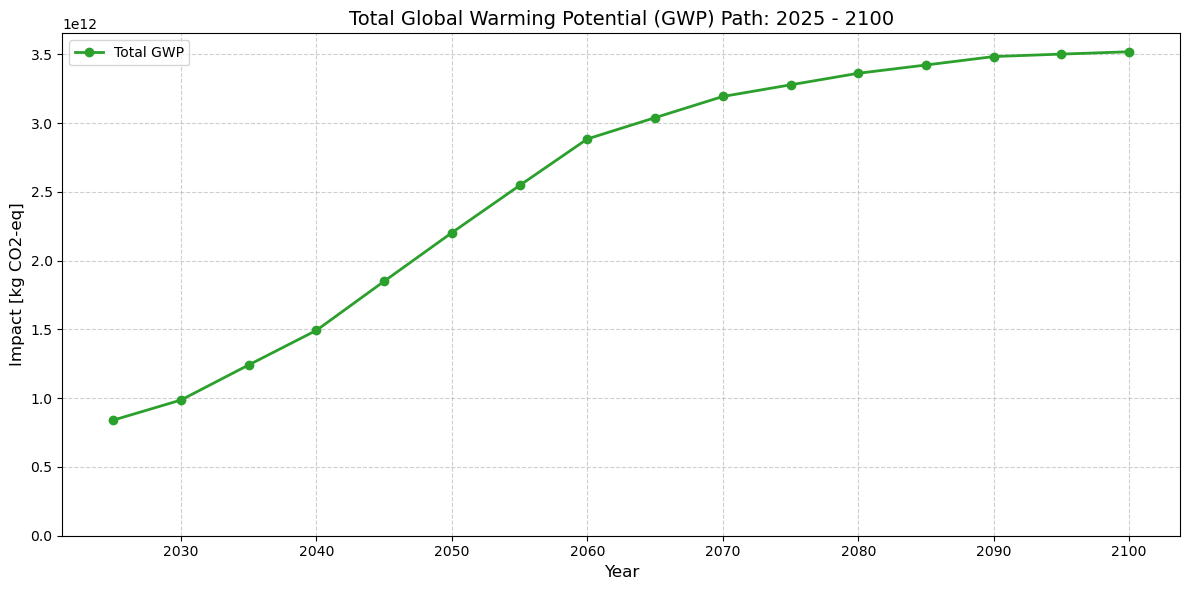

In [54]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc1.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc1.svg')
plt.show()

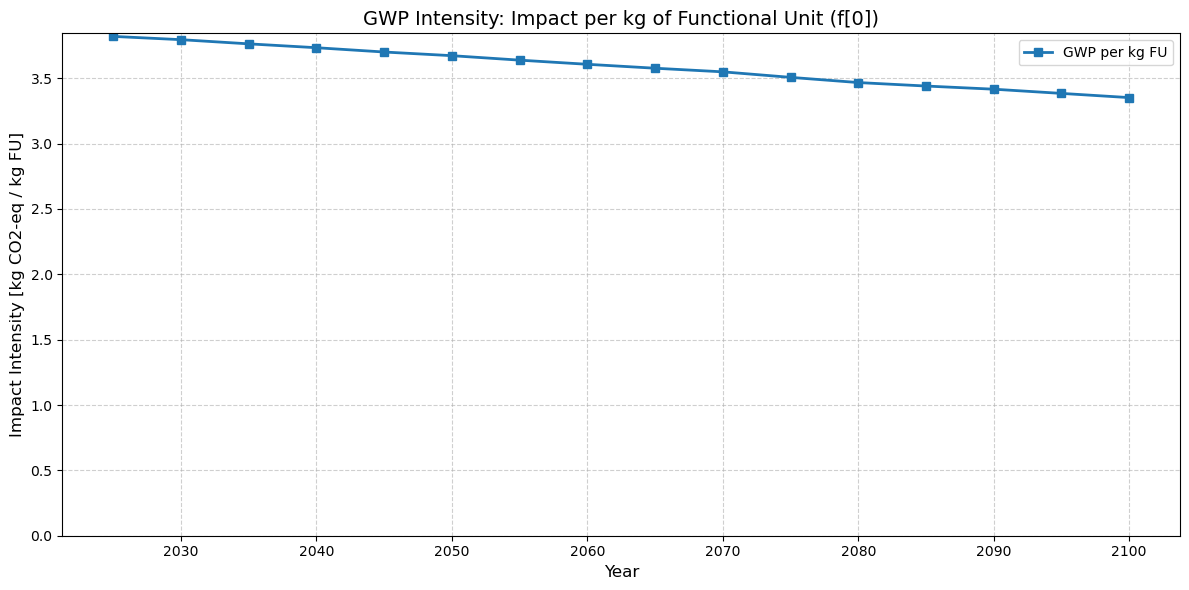

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc1 = [total / fu for total, fu in zip(list(gwp_by_year_sc1.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc1, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc1.svg')
plt.show()

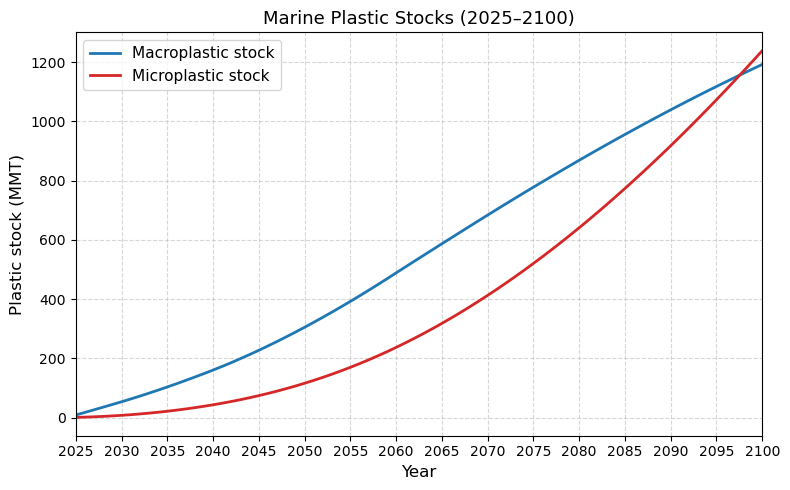

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc1.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc1.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc1.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

## Sc. 2: SSP1-2.6, passive foreground (linear economy)

In [52]:
s_results_sc2 = s_results
df_s_sc2 = df_s 
df_s_sc2.to_csv("results/scenarios/model_solutions_sc2.csv", index=False)
gwp_by_year_sc2 = gwp_by_year
map_stock_df_sc2 = map_stock_df
map_stock_df_sc2.to_csv("results/scenarios/macroplastic_stock_sc2.csv")
mip_stock_df_sc2 = mip_stock_df
mip_stock_df_sc2.to_csv("results/scenarios/microplastic_stock_sc2.csv", index=False)

### GWP

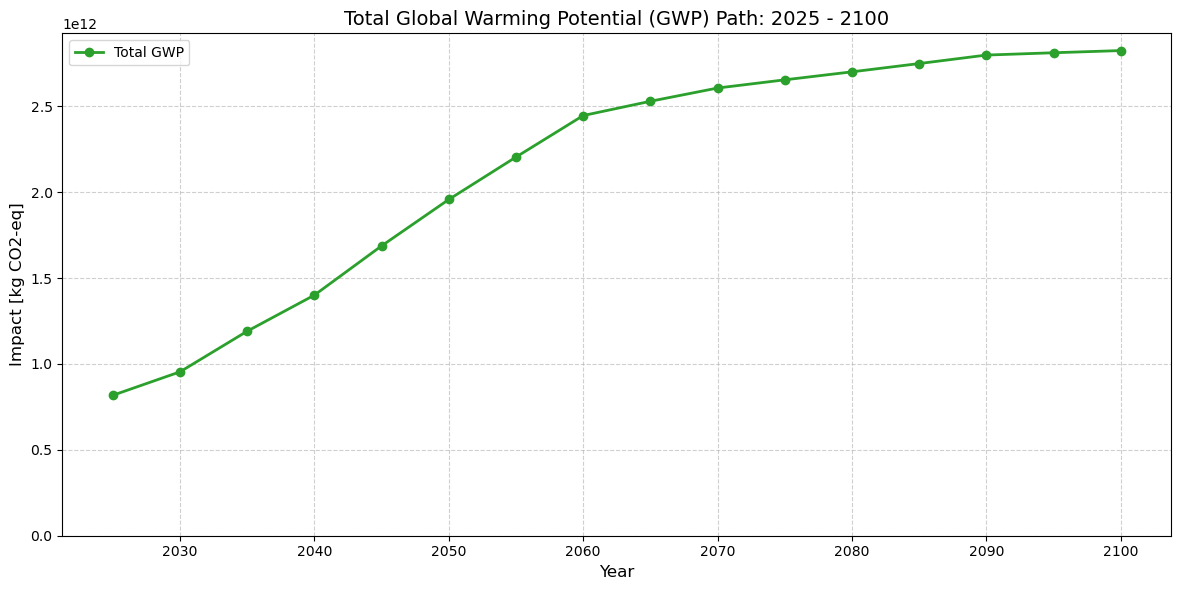

In [53]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc2.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc2.svg')
plt.show()

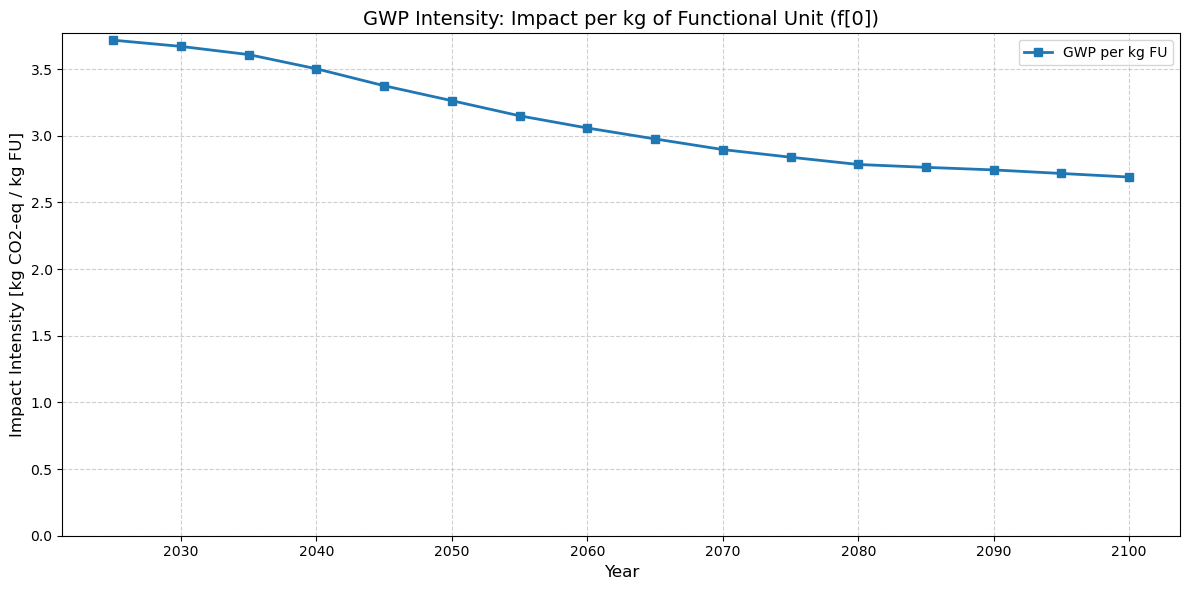

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc2 = [total / fu for total, fu in zip(list(gwp_by_year_sc2.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc2, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc2.svg')
plt.show()

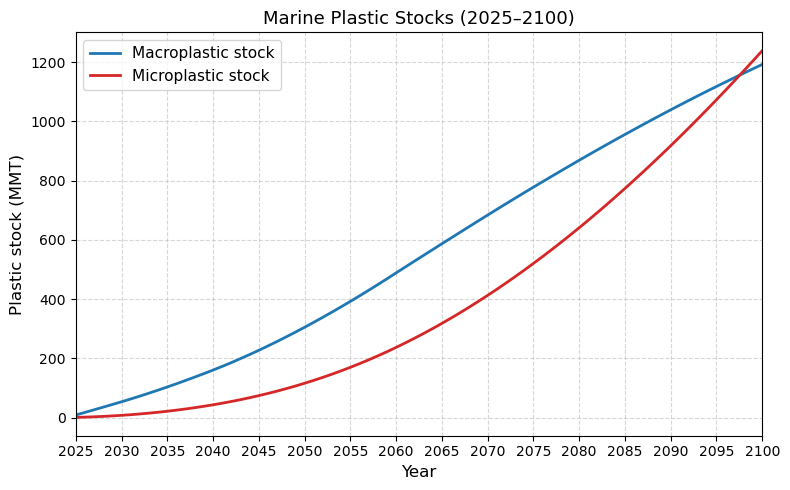

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc2.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc2.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc2.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

## Sc. 3: SSP2-4.5, market-driven foreground

In [107]:
s_results_sc3 = s_results
df_s_sc3 = df_s 
df_s_sc3.to_csv("results/scenarios/model_solutions_sc3.csv", index=False)
gwp_by_year_sc3 = gwp_by_year
map_stock_df_sc3 = map_stock_df
map_stock_df_sc3.to_csv("results/scenarios/macroplastic_stock_sc3.csv")
mip_stock_df_sc3 = mip_stock_df
mip_stock_df_sc3.to_csv("results/scenarios/microplastic_stock_sc3.csv", index=False)

### GWP

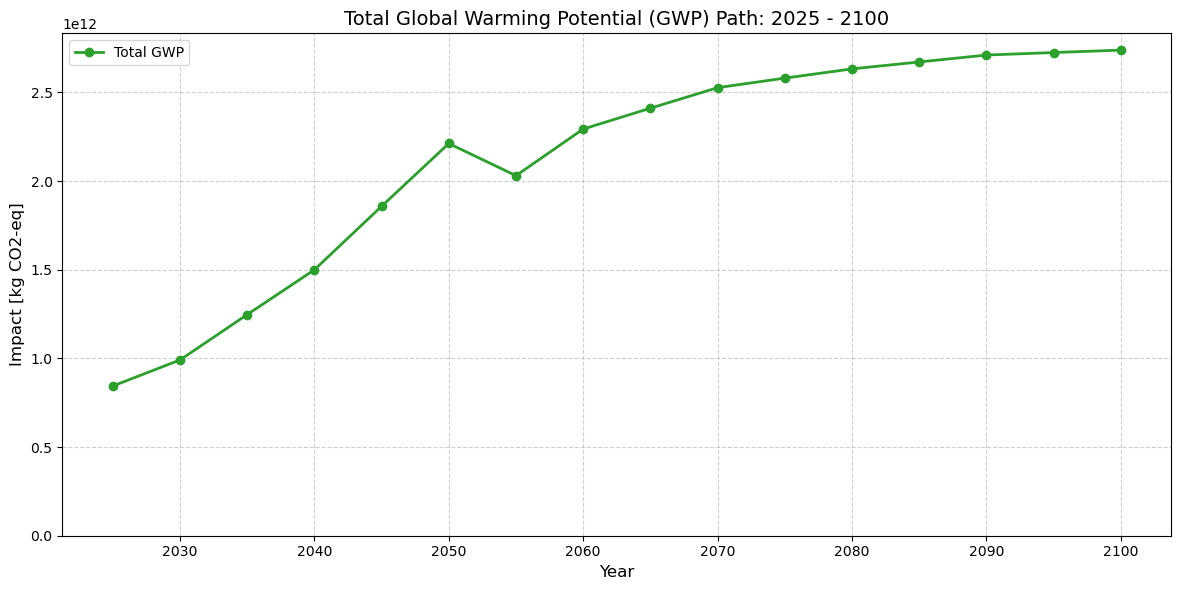

In [108]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc3.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc3.svg')
plt.show()

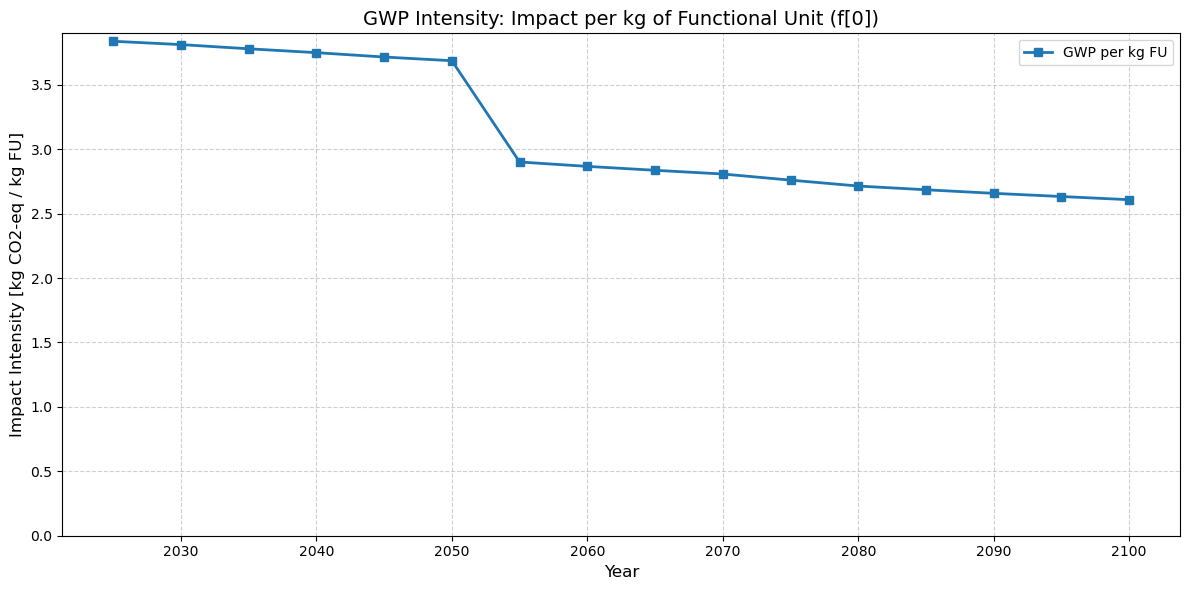

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc3 = [total / fu for total, fu in zip(list(gwp_by_year_sc3.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc3, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc3.svg')
plt.show()

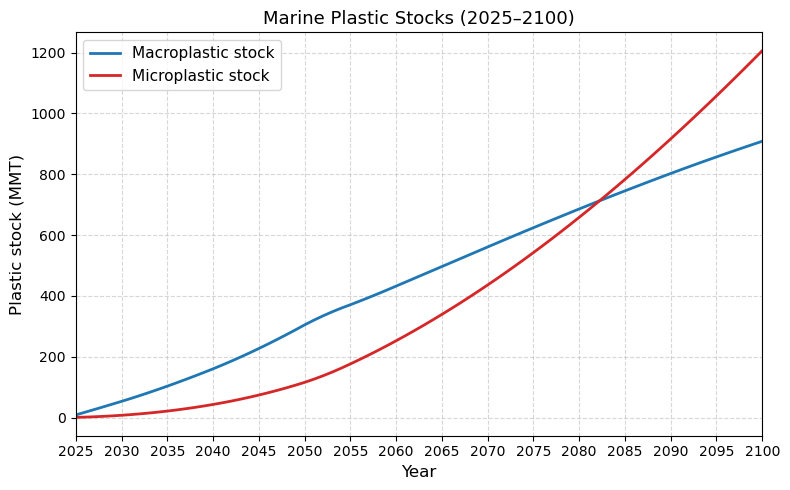

In [113]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc3.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc3.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc3.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

## Sc. 4: SSP1-2.6, market-driven foreground

In [52]:
s_results_sc4 = s_results
df_s_sc4 = df_s 
df_s_sc4.to_csv("results/scenarios/model_solutions_sc4.csv", index=False)
gwp_by_year_sc4 = gwp_by_year
map_stock_df_sc4 = map_stock_df
map_stock_df_sc4.to_csv("results/scenarios/macroplastic_stock_sc4.csv")
mip_stock_df_sc4 = mip_stock_df
mip_stock_df_sc4.to_csv("results/scenarios/microplastic_stock_sc4.csv", index=False)

### GWP

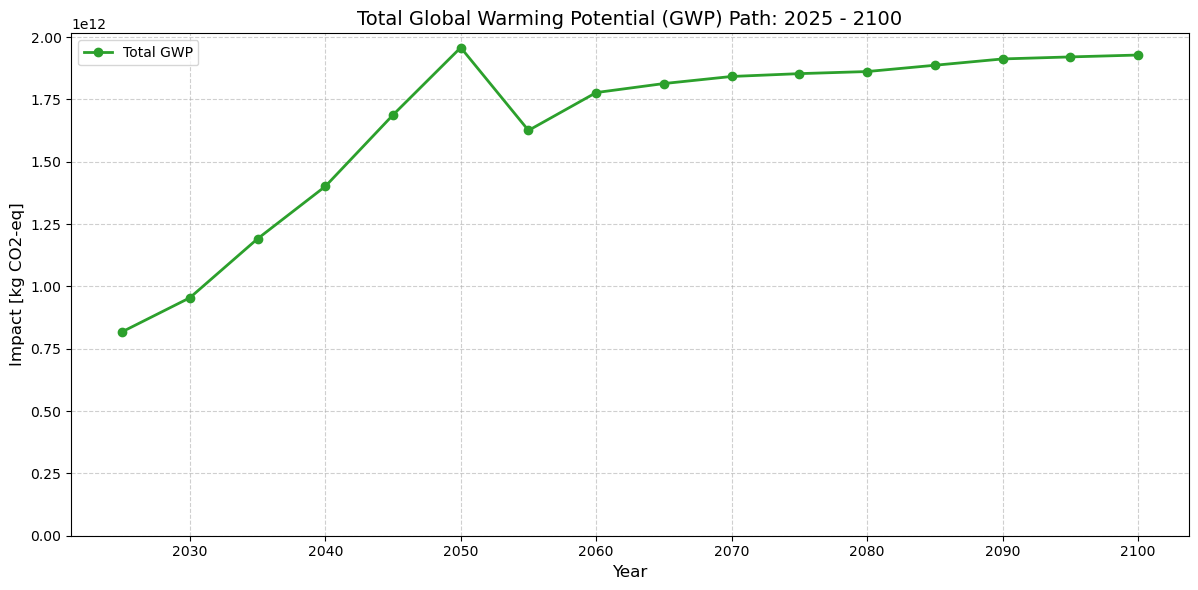

In [53]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc4.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc4.svg')
plt.show()

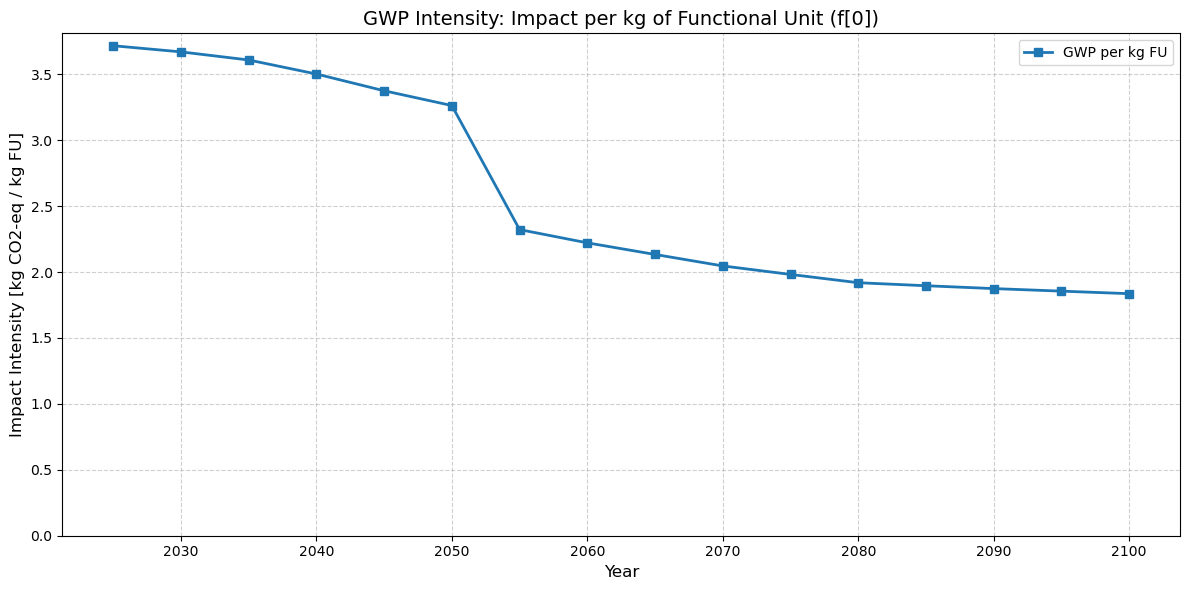

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc4 = [total / fu for total, fu in zip(list(gwp_by_year_sc4.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc4, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc4.svg')
plt.show()

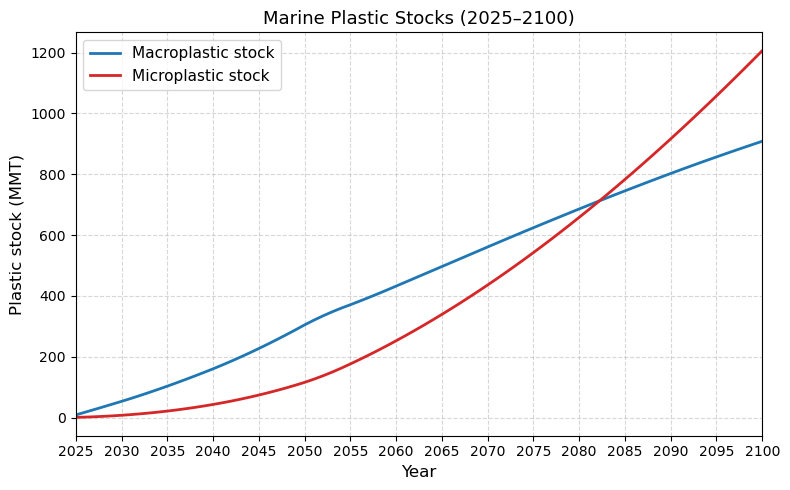

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc4.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc4.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc4.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

## Sc. 5: SSP1-2.6, net-zero carbon transition by 2100

In [135]:
s_results_sc5 = s_results
df_s_sc5 = df_s 
df_s_sc5.to_csv("results/scenarios/model_solutions_sc5.csv", index=False)
gwp_by_year_sc5 = gwp_by_year
map_stock_df_sc5 = map_stock_df
map_stock_df_sc5.to_csv("results/scenarios/macroplastic_stock_sc5.csv")
mip_stock_df_sc5 = mip_stock_df
mip_stock_df_sc5.to_csv("results/scenarios/microplastic_stock_sc5.csv", index=False)

### GWP

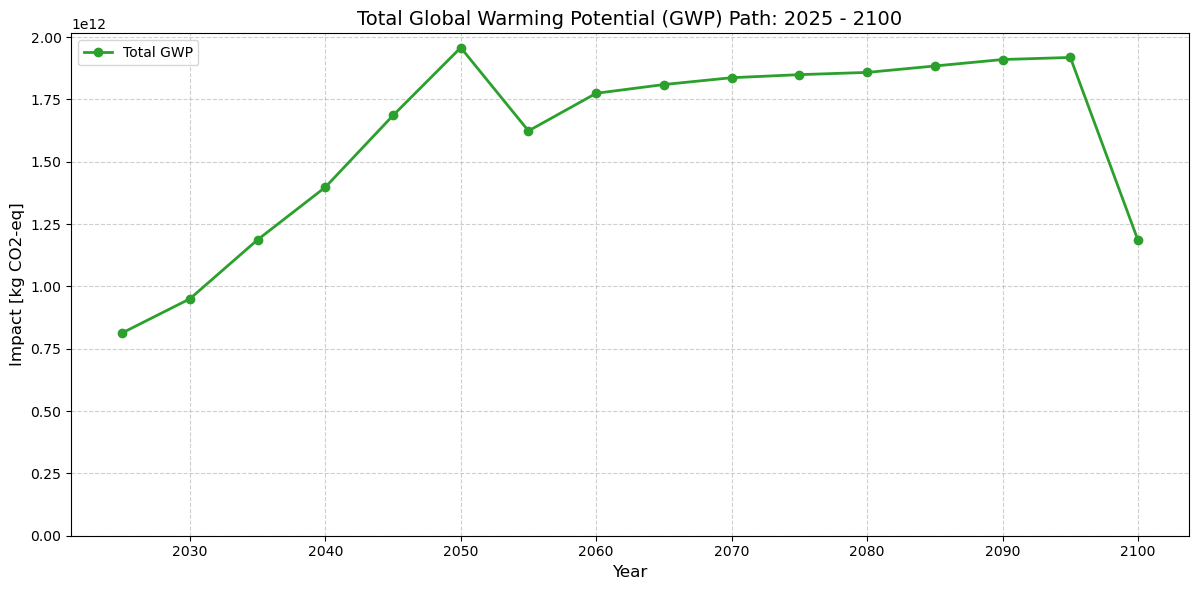

In [139]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc5.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc5.svg')
plt.show()

In [137]:
gwp_by_year_sc5.values()

dict_values([813186060260.052, 950057573761.1921, 1186891237626.101, 1397627785668.367, 1685561366038.0264, 1957754979229.6555, 1623719982605.629, 1774531201358.3115, 1809663159112.3062, 1837029099614.5732, 1849278219972.2593, 1858264277374.8171, 1884041772337.6675, 1909918906884.3037, 1918257030855.7578, 1184085804871.766])

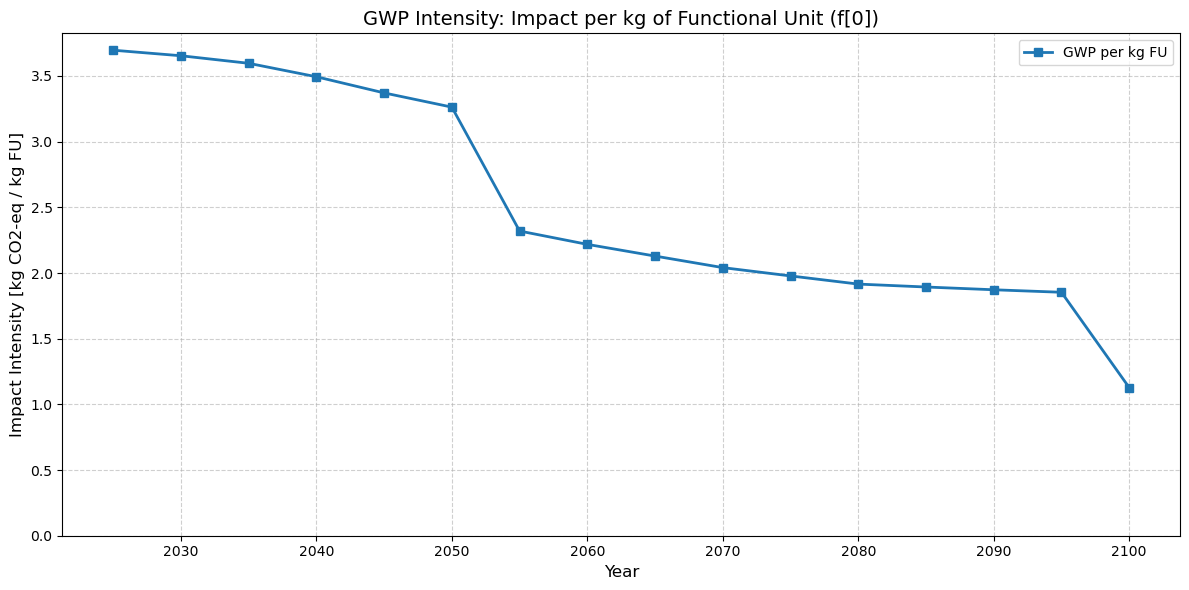

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc5 = [total / fu for total, fu in zip(list(gwp_by_year_sc5.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc5, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc5.svg')
plt.show()

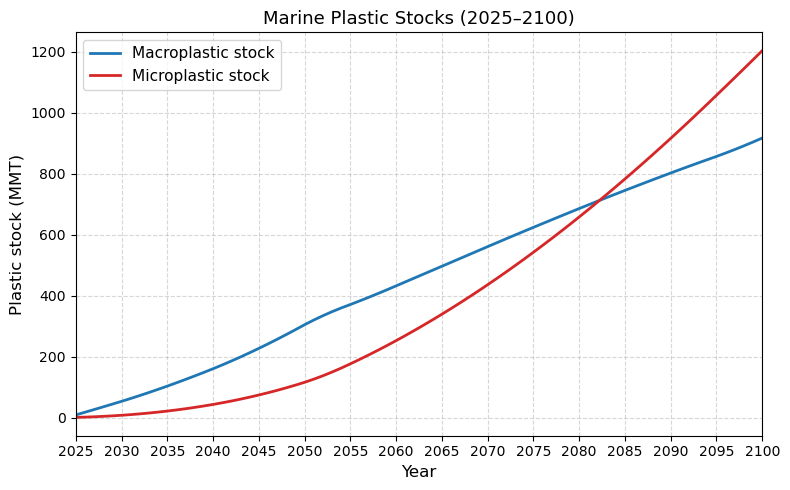

In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc5.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc5.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc5.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

## Sc. 6: SSP2-Net zero climate

In [89]:
s_results_sc6 = s_results
df_s_sc5 = df_s 
df_s_sc5.to_csv("results/scenarios/model_solutions_sc6.csv", index=False)
gwp_by_year_sc6 = gwp_by_year
map_stock_df_sc6 = map_stock_df
map_stock_df_sc6.to_csv("results/scenarios/macroplastic_stock_sc6.csv")
mip_stock_df_sc6 = mip_stock_df
mip_stock_df_sc6.to_csv("results/scenarios/microplastic_stock_sc6.csv", index=False)

### GWP

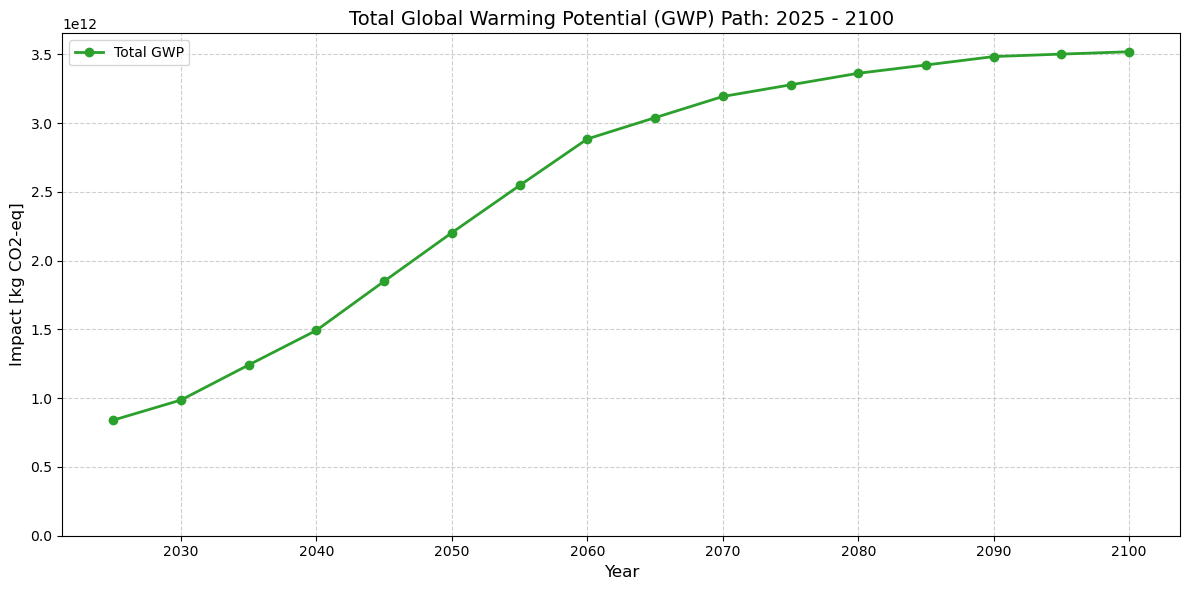

In [90]:
import matplotlib.pyplot as plt
import numpy as np
# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, list(gwp_by_year_sc6.values()), marker='o', color='tab:green', linewidth=2, label='Total GWP')

# Formatting the plot
plt.title('Total Global Warming Potential (GWP) Path: 2025 - 2100', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact [kg CO2-eq]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.ylim(bottom=0)

# Save and show
plt.savefig('Visualization/gwp_sc6.svg')
plt.show()

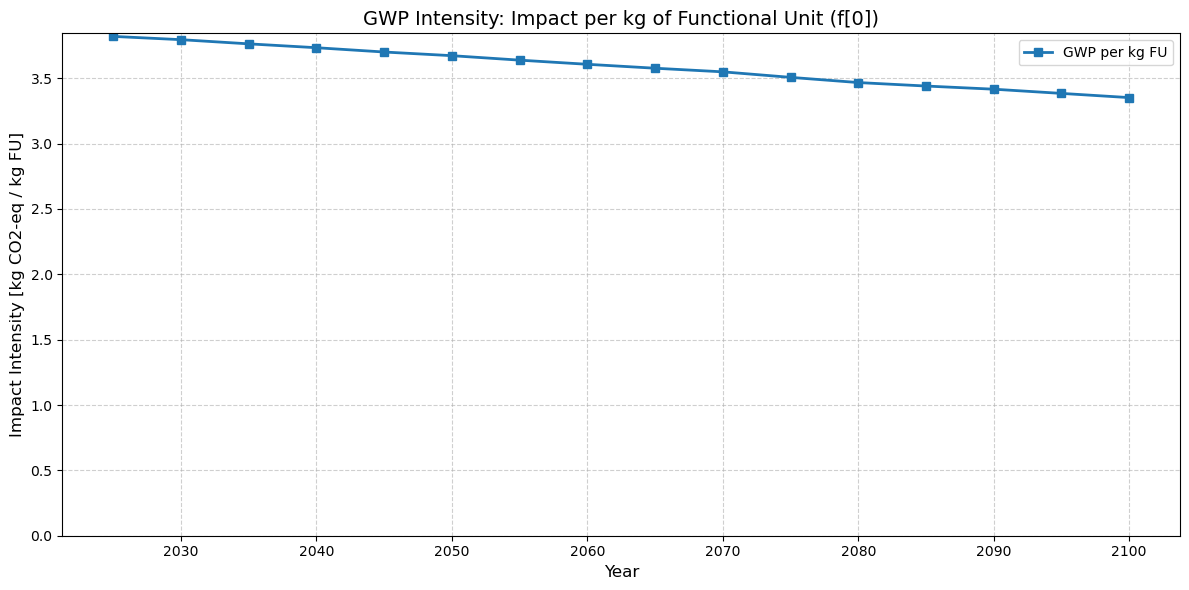

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the functional unit demand (f[0]) for each year from your data
# f_meta[t] is the numpy array for that year, index 0 is the functional unit
fu_demand_by_year = [f_meta[t][0] for t in years]

# 2. Calculate GWP per kg of Functional Unit
# Using the gwp_history calculated in the previous step
gwp_intensity_sc6 = [total / fu for total, fu in zip(list(gwp_by_year_sc6.values()), fu_demand_by_year)]

# 3. Create the Diagram
plt.figure(figsize=(12, 6))
plt.plot(years, gwp_intensity_sc6, marker='s', color='tab:blue', linewidth=2, label='GWP per kg FU')
plt.ylim(bottom=0)
# Formatting
plt.title('GWP Intensity: Impact per kg of Functional Unit (f[0])', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Impact Intensity [kg CO2-eq / kg FU]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('Visualization/gwp_intensity_sc6.svg')
plt.show()

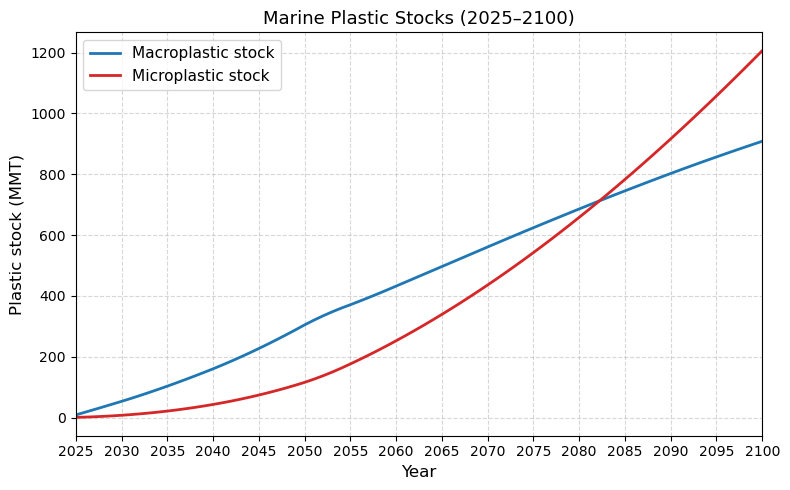

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load macro and micro stock data
map_df = pd.read_csv("results/scenarios/macroplastic_stock_sc6.csv")
mip_df = pd.read_csv("results/scenarios/microplastic_stock_sc6.csv")

# Ensure both are in MMT
map_df["MaP_stock_Mt"] = map_df["MaP_stock_kg"] / 1e9
mip_df["MiP_stock_Mt"] = mip_df["MiP_stock_kg"] / 1e9

# Merge by year
merged = pd.merge(map_df[["year", "MaP_stock_Mt"]],
                  mip_df[["year", "MiP_stock_Mt"]],
                  on="year", how="inner")

# Plot single axis with two series
plt.figure(figsize=(8,5))
plt.plot(merged["year"], merged["MaP_stock_Mt"], label="Macroplastic stock", linewidth=2, color="tab:blue")
plt.plot(merged["year"], merged["MiP_stock_Mt"], label="Microplastic stock", linewidth=2, color="tab:red")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Plastic stock (MMT)", fontsize=12)
plt.title("Marine Plastic Stocks (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.legend(fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig("Visualization/plastic_stocks_sc6.svg", format="svg")

plt.show()

In [105]:
# Sankey Diagram

# Scenario Comparison Visualization